In [5]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries loaded ✅")

Libraries loaded ✅


In [6]:
WW_URL = "https://data.cdc.gov/resource/j9g8-acpt.json"

params = {
    "$limit": 50000,
    "$where": """
        state_territory in ('ny','nj')
        AND sample_collect_date >= '2025-01-01'
        AND sample_collect_date <= '2026-08-31'
        AND source != 'WastewaterSCAN'
    """,
    "$select": """
        site,
        state_territory,
        source,
        county_fips,
        counties_served,
        population_served,
        sample_collect_date,
        sample_type,
        sample_matrix,
        sample_location,
        pcr_target_avg_conc,
        pcr_target_units,
        pcr_target_detect,
        inhibition_detect
    """
}

response = requests.get(WW_URL, params=params)
response.raise_for_status()

ww = pd.DataFrame(response.json())

print("Wastewater shape:", ww.shape)
print("Date range:", ww["sample_collect_date"].min(),
      "to", ww["sample_collect_date"].max())

ww.head()

Wastewater shape: (18861, 14)
Date range: 2025-01-01 to 2026-08-27


,site,state_territory,source,county_fips,counties_served,population_served,sample_collect_date,sample_type,sample_matrix,sample_location,pcr_target_avg_conc,pcr_target_units,pcr_target_detect,inhibition_detect
0,1262,ny,State_Territory,36015,Chemung,18085,2025-04-16,24-hr flow-weighted composite,raw wastewater,wwtp,0.0,copies/l wastewater,no,not tested
1,1319,ny,State_Territory,36053,Madison,4908,2026-02-24,grab,raw wastewater,wwtp,5128.20513,copies/l wastewater,no,not tested
2,2563,ny,State_Territory,36031,Essex,6264,2026-03-09,grab,raw wastewater,wwtp,15897.4359,copies/l wastewater,no,not tested
3,1444,ny,State_Territory,36119,Westchester,31046,2025-06-24,24-hr flow-weighted composite,raw wastewater,wwtp,0.0,copies/l wastewater,no,not tested
4,1409,ny,State_Territory,36099,Seneca,6160,2025-04-15,24-hr time-weighted composite,raw wastewater,wwtp,0.0,copies/l wastewater,no,no


In [7]:
# Basic quality check for 2025–2026 wastewater data

# Convert variables to correct types
ww["sample_collect_date"] = pd.to_datetime(ww["sample_collect_date"])
ww["pcr_target_avg_conc"] = pd.to_numeric(
    ww["pcr_target_avg_conc"], errors="coerce"
)
ww["population_served"] = pd.to_numeric(
    ww["population_served"], errors="coerce"
)

print("=== DATASET SUMMARY ===")

print("\nTotal observations:")
print(len(ww))

print("\nObservations by state:")
print(ww["state_territory"].value_counts())

print("\nUnique wastewater sites by state:")
print(
    ww.groupby("state_territory")["site"]
      .nunique()
)

print("\nUnique counties by state:")
print(
    ww.groupby("state_territory")["county_fips"]
      .nunique()
)

print("\nOverall unique sites:")
print(ww["site"].nunique())

print("\nOverall unique county FIPS:")
print(ww["county_fips"].nunique())

print("\nDate range:")
print(ww["sample_collect_date"].min(), "to",
      ww["sample_collect_date"].max())

print("\nMissing wastewater concentration:")
print(ww["pcr_target_avg_conc"].isna().sum())

print("\nSamples per site:")
site_counts = ww.groupby("site").size().sort_values(ascending=False)

print(site_counts.describe())

print("\nTop 20 sites by number of samples:")
print(site_counts.head(20))

=== DATASET SUMMARY ===

Total observations:
18861

Observations by state:
state_territory
ny    15245
nj     3616
Name: count, dtype: int64

Unique wastewater sites by state:
state_territory
nj     23
ny    169
Name: site, dtype: int64

Unique counties by state:
state_territory
nj    18
ny    62
Name: county_fips, dtype: int64

Overall unique sites:
192

Overall unique county FIPS:
80

Date range:
2025-01-01 00:00:00 to 2026-08-27 00:00:00

Missing wastewater concentration:
0

Samples per site:
count    192.000000
mean      98.234375
std       42.287006
min        1.000000
25%       72.750000
50%       87.000000
75%      125.250000
max      182.000000
dtype: float64

Top 20 sites by number of samples:
site
1202    182
1208    182
1224    182
2366    175
1206    174
1215    173
1201    173
1213    173
1216    172
1205    171
1222    170
1218    170
1223    170
1211    168
1200    165
1330    164
1225    163
1445    163
1447    162
1219    162
dtype: int64


In [8]:
# Examine monitoring coverage for each wastewater site

site_coverage = (
    ww.groupby(["site", "state_territory"])
      .agg(
          n_samples=("pcr_target_avg_conc", "size"),
          first_sample=("sample_collect_date", "min"),
          last_sample=("sample_collect_date", "max"),
          n_unique_dates=("sample_collect_date", "nunique"),
          county_fips=("county_fips", "first"),
          county=("counties_served", "first"),
          population_served=("population_served", "first")
      )
      .reset_index()
)

# Calculate number of days between first and last observation
site_coverage["monitoring_days"] = (
    site_coverage["last_sample"] -
    site_coverage["first_sample"]
).dt.days

print("=== SITE COVERAGE SUMMARY ===")

print("\nNumber of sites:")
print(len(site_coverage))

print("\nSamples per site:")
print(site_coverage["n_samples"].describe())

print("\nMonitoring span in days:")
print(site_coverage["monitoring_days"].describe())

print("\nSites with at least 40 samples:")
print((site_coverage["n_samples"] >= 40).sum())

print("\nSites with at least 60 samples:")
print((site_coverage["n_samples"] >= 60).sum())

print("\nSites with at least 80 samples:")
print((site_coverage["n_samples"] >= 80).sum())

print("\nSites monitored for at least 1 year:")
print((site_coverage["monitoring_days"] >= 365).sum())

print("\nSites with >=40 samples AND >=1 year of monitoring:")
print(
    (
        (site_coverage["n_samples"] >= 40) &
        (site_coverage["monitoring_days"] >= 365)
    ).sum()
)

=== SITE COVERAGE SUMMARY ===

Number of sites:
192

Samples per site:
count    192.000000
mean      98.234375
std       42.287006
min        1.000000
25%       72.750000
50%       87.000000
75%      125.250000
max      182.000000
Name: n_samples, dtype: float64

Monitoring span in days:
count    192.000000
mean     545.005208
std      125.617490
min        0.000000
25%      580.750000
50%      588.000000
75%      593.000000
max      603.000000
Name: monitoring_days, dtype: float64

Sites with at least 40 samples:
176

Sites with at least 60 samples:
167

Sites with at least 80 samples:
120

Sites monitored for at least 1 year:
178

Sites with >=40 samples AND >=1 year of monitoring:
174


In [9]:
# Look for county fields that may contain multiple counties

multi_county = ww[
    ww["counties_served"].astype(str).str.contains(
        r"[,;|]", regex=True, na=False
    )
]

print("Rows that appear to serve multiple counties:")
print(len(multi_county))

if len(multi_county) > 0:
    display(
        multi_county[
            ["site", "state_territory", "county_fips", "counties_served"]
        ].drop_duplicates().head(20)
    )

Rows that appear to serve multiple counties:
620


,site,state_territory,county_fips,counties_served
177,1310,ny,"36081, 36061, 36047","New York, Queens, Kings"
282,1388,ny,"36005, 36061","New York, Bronx"
2250,1206,nj,"34013, 34003, 34039, 34031, 34017","Union, Passaic, Bergen, Hudson, Essex"
2269,1213,nj,"34039, 34035, 34023","Somerset, Middlesex, Union"
2285,1224,nj,"34013, 34039","Union, Essex"
2312,2600,nj,"34013, 34003, 34039, 34031, 34017","Union, Passaic, Bergen, Hudson, Essex"


In [10]:
# Flag wastewater sites that serve multiple counties

ww["is_multi_county"] = (
    ww["county_fips"]
    .astype(str)
    .str.contains(",", na=False)
)

# Count unique sites
multi_sites = ww.loc[
    ww["is_multi_county"], "site"
].nunique()

single_sites = ww.loc[
    ~ww["is_multi_county"], "site"
].nunique()

print("Unique multi-county sites:", multi_sites)
print("Unique single-county sites:", single_sites)

print("\nMulti-county sites by state:")
print(
    ww.loc[ww["is_multi_county"]]
      .groupby("state_territory")["site"]
      .nunique()
)

print("\nSingle-county sites by state:")
print(
    ww.loc[~ww["is_multi_county"]]
      .groupby("state_territory")["site"]
      .nunique()
)

Unique multi-county sites: 6
Unique single-county sites: 187

Multi-county sites by state:
state_territory
nj    4
ny    2
Name: site, dtype: int64

Single-county sites by state:
state_territory
nj     19
ny    168
Name: site, dtype: int64


In [11]:
# Check whether any site appears as both single-county and multi-county

multi_site_ids = set(
    ww.loc[ww["is_multi_county"], "site"].unique()
)

single_site_ids = set(
    ww.loc[~ww["is_multi_county"], "site"].unique()
)

overlap_sites = multi_site_ids.intersection(single_site_ids)

print("Sites appearing in BOTH categories:")
print(overlap_sites)

if overlap_sites:
    display(
        ww.loc[
            ww["site"].isin(overlap_sites),
            [
                "site",
                "state_territory",
                "sample_collect_date",
                "county_fips",
                "counties_served"
            ]
        ]
        .drop_duplicates()
        .sort_values(["site", "sample_collect_date"])
    )

Sites appearing in BOTH categories:
{'1310'}


,site,state_territory,sample_collect_date,county_fips,counties_served
18257,1310,ny,2025-01-05,36047,Kings
12725,1310,ny,2025-01-07,36047,Kings
3956,1310,ny,2025-01-12,36047,Kings
16746,1310,ny,2025-01-14,36047,Kings
3486,1310,ny,2025-01-21,36047,Kings
...,...,...,...,...,...
12090,1310,ny,2026-04-14,36047,Kings
11662,1310,ny,2026-04-19,36047,Kings
3638,1310,ny,2026-04-21,36047,Kings
11742,1310,ny,2026-04-26,36047,Kings


In [12]:
# Classify a site as multi-county if it was EVER
# reported as serving multiple counties

site_multi_status = (
    ww.groupby("site")["is_multi_county"]
      .max()
      .reset_index()
)

site_multi_status["site_type"] = np.where(
    site_multi_status["is_multi_county"],
    "Multi-county",
    "Single-county"
)

print(site_multi_status["site_type"].value_counts())
print("\nTotal sites:", len(site_multi_status))

site_type
Single-county    186
Multi-county       6
Name: count, dtype: int64

Total sites: 192


In [13]:
# Merge county-service classification into site coverage

site_coverage = site_coverage.drop(
    columns=["is_multi_county"],
    errors="ignore"
)

site_coverage = site_coverage.merge(
    site_multi_status[
        ["site", "is_multi_county", "site_type"]
    ],
    on="site",
    how="left"
)

# Define primary analytic eligibility
site_coverage["eligible_primary"] = (
    (site_coverage["n_samples"] >= 40) &
    (site_coverage["monitoring_days"] >= 365) &
    (~site_coverage["is_multi_county"])
)

eligible_sites = site_coverage.loc[
    site_coverage["eligible_primary"]
].copy()

print("=== PRIMARY ANALYTIC SAMPLE ===")

print("\nTotal eligible sites:")
print(len(eligible_sites))

print("\nEligible sites by state:")
print(
    eligible_sites.groupby("state_territory")["site"]
                  .nunique()
)

print("\nUnique eligible counties:")
print(eligible_sites["county_fips"].nunique())

print("\nSamples per eligible site:")
print(eligible_sites["n_samples"].describe())

=== PRIMARY ANALYTIC SAMPLE ===

Total eligible sites:
169

Eligible sites by state:
state_territory
nj     18
ny    151
Name: site, dtype: int64

Unique eligible counties:
72

Samples per eligible site:
count    169.000000
mean     104.502959
std       35.335151
min       46.000000
25%       76.000000
50%       99.000000
75%      130.000000
max      182.000000
Name: n_samples, dtype: float64


In [14]:
# CDC NSSP Emergency Department Visit Trajectories
# COVID-19, Influenza, RSV, and combined respiratory illness

ED_URL = "https://data.cdc.gov/resource/rdmq-nq56.json"

params = {
    "$limit": 50000,
    "$where": """
        week_end >= '2025-01-01'
        AND week_end <= '2026-08-31'
    """
}

response = requests.get(ED_URL, params=params)
response.raise_for_status()

ed = pd.DataFrame(response.json())

print("ED dataset shape:", ed.shape)

print("\nColumns:")
print(ed.columns.tolist())

print("\nFirst 5 rows:")
display(ed.head())

ED dataset shape: (50000, 18)

Columns:
['week_end', 'geography', 'county', 'percent_visits_covid', 'percent_visits_influenza', 'percent_visits_rsv', 'percent_visits_smoothed_covid', 'percent_visits_smoothed_1', 'percent_visits_smoothed_rsv', 'ed_trends_covid', 'ed_trends_influenza', 'ed_trends_rsv', 'hsa', 'hsa_counties', 'hsa_nci_id', 'fips', 'trend_source', 'buildnumber']

First 5 rows:


,week_end,geography,county,percent_visits_covid,percent_visits_influenza,percent_visits_rsv,percent_visits_smoothed_covid,percent_visits_smoothed_1,percent_visits_smoothed_rsv,ed_trends_covid,ed_trends_influenza,ed_trends_rsv,hsa,hsa_counties,hsa_nci_id,fips,trend_source,buildnumber
0,2025-01-04T00:00:00.000,Alabama,All,1.1,7.76,1.12,1.12,8.63,1.23,Increasing,Increasing,No Change,All,All,All,1000,State,2026-09-02
1,2025-01-04T00:00:00.000,Alabama,Baldwin,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Mobile (Mobile), AL - Baldwin, AL","Baldwin, Clarke, Mobile, Monroe, Washington",161,1003,HSA,2026-09-02
2,2025-01-04T00:00:00.000,Alabama,Barbour,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Houston (Dothan), AL - Dale, AL","Barbour, Coffee, Dale, Geneva, Henry, Houston",162,1005,HSA,2026-09-02
3,2025-01-04T00:00:00.000,Alabama,Chambers,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Chambers, AL - Randolph, AL","Chambers, Randolph",172,1017,HSA,2026-09-02
4,2025-01-04T00:00:00.000,Alabama,Conecuh,NaN,NaN,NaN,NaN,NaN,NaN,Data Unavailable,Data Unavailable,Data Unavailable,"Escambia, AL - Conecuh, AL","Conecuh, Escambia",163,1035,HSA,2026-09-02


In [15]:
# Pull only New York and New Jersey ED surveillance data

ED_URL = "https://data.cdc.gov/resource/rdmq-nq56.json"

params = {
    "$limit": 50000,
    "$where": """
        geography in ('New York', 'New Jersey')
        AND week_end >= '2025-01-01'
        AND week_end <= '2026-08-31'
    """
}

response = requests.get(ED_URL, params=params)
response.raise_for_status()

ed_nynj = pd.DataFrame(response.json())

print("NY/NJ ED dataset shape:", ed_nynj.shape)

print("\nRows by state:")
print(ed_nynj["geography"].value_counts())

print("\nTrend source:")
print(ed_nynj["trend_source"].value_counts(dropna=False))

print("\nUnique county FIPS by state:")
print(
    ed_nynj.groupby("geography")["fips"]
           .nunique()
)

print("\nUnique HSAs by state:")
print(
    ed_nynj.groupby("geography")["hsa_nci_id"]
           .nunique()
)

display(ed_nynj.head(10))

NY/NJ ED dataset shape: (7395, 18)

Rows by state:
geography
New York      5481
New Jersey    1914
Name: count, dtype: int64

Trend source:
trend_source
HSA      7221
State     174
Name: count, dtype: int64

Unique county FIPS by state:
geography
New Jersey    22
New York      63
Name: fips, dtype: int64

Unique HSAs by state:
geography
New Jersey    10
New York      22
Name: hsa_nci_id, dtype: int64


,week_end,geography,county,percent_visits_covid,percent_visits_influenza,percent_visits_rsv,percent_visits_smoothed_covid,percent_visits_smoothed_1,percent_visits_smoothed_rsv,ed_trends_covid,ed_trends_influenza,ed_trends_rsv,hsa,hsa_counties,hsa_nci_id,fips,trend_source,buildnumber
0,2025-01-04T00:00:00.000,New Jersey,Monmouth,2.26,6.14,1.37,1.91,6.4,1.33,No Change,Increasing,Decreasing,"Monmouth, NJ - Ocean (Brick Township), NJ","Monmouth, Ocean",108,34025,HSA,2026-09-02
1,2025-01-04T00:00:00.000,New Jersey,Somerset,1.07,7.07,0.99,1.09,6.97,0.88,Increasing,Increasing,Decreasing,"Essex (Newark), NJ - Middlesex, NJ","Essex, Middlesex, Somerset, Union",66,34035,HSA,2026-09-02
2,2025-01-04T00:00:00.000,New York,Broome,1.39,6.03,0.86,0.91,5.63,0.87,No Change,Decreasing,Increasing,"Broome (Binghamton), NY - Tioga, NY","Broome, Tioga",19,36007,HSA,2026-09-02
3,2025-01-04T00:00:00.000,New York,Cattaraugus,2.65,0.96,0.72,1.95,0.72,0.66,Increasing,Increasing,No Change,"Cattaraugus, NY - Allegany, NY","Allegany, Cattaraugus",35,36009,HSA,2026-09-02
4,2025-01-04T00:00:00.000,New York,Dutchess,1.83,7.68,1.77,1.55,6.82,1.67,No Change,Increasing,Decreasing,"Westchester (Yonkers), NY - Dutchess, NY","Dutchess, Putnam, Ulster, Westchester",41,36027,HSA,2026-09-02
5,2025-01-04T00:00:00.000,New York,Franklin,1.81,2.55,1.02,1.8,2.01,0.92,No Change,Increasing,No Change,"Clinton, NY - Franklin, NY","Clinton, Essex, Franklin",81,36033,HSA,2026-09-02
6,2025-01-04T00:00:00.000,New York,Fulton,1.42,1.49,1.81,1.76,1.68,1.8,No Change,Increasing,No Change,"Fulton, NY - Montgomery (Amsterdam), NY","Fulton, Montgomery",76,36035,HSA,2026-09-02
7,2025-01-04T00:00:00.000,New York,Greene,2.11,3.16,0.63,1.86,3.1,0.45,No Change,Increasing,Limited Data,"Columbia, NY - Greene, NY","Columbia, Greene",881,36039,HSA,2026-09-02
8,2025-01-04T00:00:00.000,New York,Hamilton,2.44,4.02,0.83,1.74,3.42,0.89,No Change,Increasing,No Change,"Saratoga, NY - Schenectady (Schenectady), NY","Hamilton, Saratoga, Schenectady, Warren, Washi...",88,36041,HSA,2026-09-02
9,2025-01-04T00:00:00.000,New York,Jefferson,1.2,3.6,1.78,1.09,4.25,1.41,No Change,No Change,No Change,"St. Lawrence, NY - Jefferson, NY","Jefferson, Lewis, St. Lawrence",80,36045,HSA,2026-09-02


In [16]:
# Keep HSA-level rows only
ed_hsa = ed_nynj.loc[
    ed_nynj["trend_source"] == "HSA"
].copy()

# Convert variables
ed_hsa["week_end"] = pd.to_datetime(ed_hsa["week_end"])

ed_hsa["percent_visits_covid"] = pd.to_numeric(
    ed_hsa["percent_visits_covid"],
    errors="coerce"
)

ed_hsa["percent_visits_smoothed_covid"] = pd.to_numeric(
    ed_hsa["percent_visits_smoothed_covid"],
    errors="coerce"
)

# Check whether multiple county rows within the same HSA/week
# contain the same ED estimate
hsa_week_check = (
    ed_hsa.groupby(
        ["geography", "hsa_nci_id", "week_end"]
    )
    .agg(
        n_county_rows=("county", "nunique"),
        n_unique_raw_covid=("percent_visits_covid", "nunique"),
        n_unique_smoothed_covid=("percent_visits_smoothed_covid", "nunique")
    )
    .reset_index()
)

print("=== HSA-WEEK DUPLICATION CHECK ===")

print("\nCounty rows per HSA-week:")
print(hsa_week_check["n_county_rows"].describe())

print("\nHSA-weeks with MORE THAN ONE raw COVID ED value:")
print(
    (hsa_week_check["n_unique_raw_covid"] > 1).sum()
)

print("\nHSA-weeks with MORE THAN ONE smoothed COVID ED value:")
print(
    (hsa_week_check["n_unique_smoothed_covid"] > 1).sum()
)

print("\nExample:")
display(hsa_week_check.head(15))

=== HSA-WEEK DUPLICATION CHECK ===

County rows per HSA-week:
count    2610.000000
mean        2.766667
std         1.358773
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max         7.000000
Name: n_county_rows, dtype: float64

HSA-weeks with MORE THAN ONE raw COVID ED value:
0

HSA-weeks with MORE THAN ONE smoothed COVID ED value:
0

Example:


,geography,hsa_nci_id,week_end,n_county_rows,n_unique_raw_covid,n_unique_smoothed_covid
0,New Jersey,108,2025-01-04,2,1,1
1,New Jersey,108,2025-01-11,2,1,1
2,New Jersey,108,2025-01-18,2,1,1
3,New Jersey,108,2025-01-25,2,1,1
4,New Jersey,108,2025-02-01,2,1,1
5,New Jersey,108,2025-02-08,2,1,1
6,New Jersey,108,2025-02-15,2,1,1
7,New Jersey,108,2025-02-22,2,1,1
8,New Jersey,108,2025-03-01,2,1,1
9,New Jersey,108,2025-03-08,2,1,1


In [17]:
# Create county-to-HSA crosswalk from CDC ED data

county_hsa_check = (
    ed_hsa.groupby(["geography", "fips"])
    .agg(
        county=("county", "first"),
        n_hsas=("hsa_nci_id", "nunique"),
        hsa_nci_id=("hsa_nci_id", "first"),
        hsa=("hsa", "first"),
        hsa_counties=("hsa_counties", "first")
    )
    .reset_index()
)

print("=== COUNTY → HSA CHECK ===")

print("\nCounties mapping to MORE THAN ONE HSA:")
print((county_hsa_check["n_hsas"] > 1).sum())

print("\nCounty counts by state:")
print(
    county_hsa_check.groupby("geography")["fips"].nunique()
)

display(county_hsa_check.head(15))

=== COUNTY → HSA CHECK ===

Counties mapping to MORE THAN ONE HSA:
0

County counts by state:
geography
New Jersey    21
New York      62
Name: fips, dtype: int64


,geography,fips,county,n_hsas,hsa_nci_id,hsa,hsa_counties
0,New Jersey,34001,Atlantic,1,64,"Atlantic (Atlantic City), NJ - Cape May, NJ","Atlantic, Cape May"
1,New Jersey,34003,Bergen,1,36,"Bergen, NJ - Hudson (Jersey City), NJ","Bergen, Hudson, Passaic"
2,New Jersey,34005,Burlington,1,23,"Camden (Camden), NJ - Burlington, NJ","Burlington, Camden, Gloucester, Salem"
3,New Jersey,34007,Camden,1,23,"Camden (Camden), NJ - Burlington, NJ","Burlington, Camden, Gloucester, Salem"
4,New Jersey,34009,Cape May,1,64,"Atlantic (Atlantic City), NJ - Cape May, NJ","Atlantic, Cape May"
5,New Jersey,34011,Cumberland,1,127,"Cumberland, NJ",Cumberland
6,New Jersey,34013,Essex,1,66,"Essex (Newark), NJ - Middlesex, NJ","Essex, Middlesex, Somerset, Union"
7,New Jersey,34015,Gloucester,1,23,"Camden (Camden), NJ - Burlington, NJ","Burlington, Camden, Gloucester, Salem"
8,New Jersey,34017,Hudson,1,36,"Bergen, NJ - Hudson (Jersey City), NJ","Bergen, Hudson, Passaic"
9,New Jersey,34019,Hunterdon,1,93,"Hunterdon, NJ - Warren (Phillipsburg), NJ","Hunterdon, Warren"


In [19]:
county_hsa = (
    county_hsa_check.loc[
        county_hsa_check["n_hsas"] == 1,
        [
            "geography",
            "fips",
            "county",
            "hsa_nci_id",
            "hsa",
            "hsa_counties"
        ]
    ]
    .drop_duplicates()
    .copy()
)

# Make sure FIPS codes are formatted the same way
county_hsa["fips"] = (
    county_hsa["fips"]
    .astype(str)
    .str.zfill(5)
)

eligible_sites["county_fips"] = (
    eligible_sites["county_fips"]
    .astype(str)
    .str.zfill(5)
)

print("County-HSA crosswalk rows:", len(county_hsa))

County-HSA crosswalk rows: 83


In [20]:
eligible_sites_hsa = eligible_sites.merge(
    county_hsa,
    left_on="county_fips",
    right_on="fips",
    how="left"
)

print("=== WASTEWATER → HSA MATCH ===")

print("\nEligible wastewater sites:")
print(len(eligible_sites_hsa))

print("\nSites successfully mapped to an HSA:")
print(eligible_sites_hsa["hsa_nci_id"].notna().sum())

print("\nSites NOT mapped:")
print(eligible_sites_hsa["hsa_nci_id"].isna().sum())

print("\nUnique wastewater counties represented:")
print(eligible_sites_hsa["county_fips"].nunique())

print("\nUnique HSAs represented:")
print(eligible_sites_hsa["hsa_nci_id"].nunique())

=== WASTEWATER → HSA MATCH ===

Eligible wastewater sites:
169

Sites successfully mapped to an HSA:
169

Sites NOT mapped:
0

Unique wastewater counties represented:
72

Unique HSAs represented:
29


In [21]:
# ============================================================
# CREATE WEEKLY STANDARDIZED WASTEWATER SIGNALS
# ============================================================

# Keep only eligible wastewater sites
eligible_site_ids = eligible_sites_hsa["site"].unique()

ww_analysis = ww.loc[
    ww["site"].isin(eligible_site_ids)
].copy()

# Attach HSA information to each wastewater observation
site_hsa_map = (
    eligible_sites_hsa[
        ["site", "hsa_nci_id", "hsa", "geography"]
    ]
    .drop_duplicates(subset="site")
)

ww_analysis = ww_analysis.merge(
    site_hsa_map,
    on="site",
    how="left"
)

# Make sure concentration is numeric
ww_analysis["pcr_target_avg_conc"] = pd.to_numeric(
    ww_analysis["pcr_target_avg_conc"],
    errors="coerce"
)

# Log-transform wastewater concentration
# log1p allows us to keep legitimate zero values
ww_analysis["log_conc"] = np.log1p(
    ww_analysis["pcr_target_avg_conc"]
)

# Standardize within each wastewater site
# This tells us how high/low the wastewater level is
# relative to that site's own historical pattern
def zscore_site(x):
    sd = x.std(ddof=0)

    if sd == 0:
        return pd.Series(np.nan, index=x.index)

    return (x - x.mean()) / sd

ww_analysis["ww_z"] = (
    ww_analysis.groupby("site")["log_conc"]
               .transform(zscore_site)
)

# Map each sample to the CDC ED week ending Saturday
ww_analysis["week_end"] = (
    ww_analysis["sample_collect_date"]
    + pd.to_timedelta(
        (5 - ww_analysis["sample_collect_date"].dt.weekday) % 7,
        unit="D"
    )
)

print("Wastewater observations:", len(ww_analysis))
print("Unique sites:", ww_analysis["site"].nunique())
print("Unique HSAs:", ww_analysis["hsa_nci_id"].nunique())

print("\nWastewater z-score summary:")
print(ww_analysis["ww_z"].describe())

Wastewater observations: 17661
Unique sites: 169
Unique HSAs: 29

Wastewater z-score summary:
count    1.766100e+04
mean    -2.675448e-17
std      1.000028e+00
min     -7.568417e+00
25%     -5.537397e-01
50%      3.575449e-01
75%      6.886444e-01
max      2.839257e+00
Name: ww_z, dtype: float64


In [22]:
# ============================================================
# COLLAPSE TO ONE OBSERVATION PER SITE PER WEEK
# ============================================================

ww_site_weekly = (
    ww_analysis.groupby(
        ["site", "hsa_nci_id", "geography", "week_end"]
    )
    .agg(
        ww_z=("ww_z", "mean"),
        log_conc=("log_conc", "mean"),
        n_samples=("ww_z", "size"),
        population_served=("population_served", "first")
    )
    .reset_index()
)

print("=== SITE-WEEK DATA ===")

print("\nRows:")
print(len(ww_site_weekly))

print("\nUnique sites:")
print(ww_site_weekly["site"].nunique())

print("\nUnique HSAs:")
print(ww_site_weekly["hsa_nci_id"].nunique())

print("\nWeeks per site:")
print(
    ww_site_weekly.groupby("site")["week_end"]
                  .nunique()
                  .describe()
)

print("\nSamples contributing to each site-week:")
print(
    ww_site_weekly["n_samples"].describe()
)

=== SITE-WEEK DATA ===

Rows:
12799

Unique sites:
169

Unique HSAs:
29

Weeks per site:
count    169.000000
mean      75.733728
std        9.659999
min       38.000000
25%       71.000000
50%       78.000000
75%       83.000000
max       87.000000
Name: week_end, dtype: float64

Samples contributing to each site-week:
count    12799.000000
mean         1.379873
std          0.504477
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: n_samples, dtype: float64


In [23]:
# ============================================================
# COLLAPSE TO ONE WASTEWATER SIGNAL PER HSA PER WEEK
# ============================================================

ww_hsa_weekly = (
    ww_site_weekly.groupby(
        ["geography", "hsa_nci_id", "week_end"]
    )
    .agg(
        wastewater_z=("ww_z", "mean"),
        n_sites=("site", "nunique")
    )
    .reset_index()
)

print("=== HSA-WEEK WASTEWATER DATA ===")

print("\nRows:")
print(len(ww_hsa_weekly))

print("\nUnique HSAs:")
print(ww_hsa_weekly["hsa_nci_id"].nunique())

print("\nUnique weeks:")
print(ww_hsa_weekly["week_end"].nunique())

print("\nDate range:")
print(
    ww_hsa_weekly["week_end"].min(),
    "to",
    ww_hsa_weekly["week_end"].max()
)

print("\nSites contributing per HSA-week:")
print(
    ww_hsa_weekly["n_sites"].describe()
)

print("\nWeeks available per HSA:")
print(
    ww_hsa_weekly.groupby("hsa_nci_id")["week_end"]
                 .nunique()
                 .describe()
)

=== HSA-WEEK WASTEWATER DATA ===

Rows:
2467

Unique HSAs:
29

Unique weeks:
87

Date range:
2025-01-04 00:00:00 to 2026-08-29 00:00:00

Sites contributing per HSA-week:
count    2467.000000
mean        5.188083
std         4.478331
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        23.000000
Name: n_sites, dtype: float64

Weeks available per HSA:
count    29.000000
mean     85.068966
std       3.584999
min      69.000000
25%      86.000000
50%      86.000000
75%      86.000000
max      87.000000
Name: week_end, dtype: float64


In [24]:
# ============================================================
# CREATE CLEAN HSA-WEEK COVID ED DATA
# ============================================================

ed_hsa_weekly = (
    ed_hsa.groupby(
        ["geography", "hsa_nci_id", "week_end"]
    )
    .agg(
        covid_ed_pct=("percent_visits_covid", "first"),
        covid_ed_pct_smoothed=("percent_visits_smoothed_covid", "first"),
        covid_ed_trend=("ed_trends_covid", "first"),
        hsa=("hsa", "first"),
        hsa_counties=("hsa_counties", "first")
    )
    .reset_index()
)

print("=== CLEAN HSA CLINICAL DATA ===")

print("\nRows:")
print(len(ed_hsa_weekly))

print("\nUnique HSAs:")
print(ed_hsa_weekly["hsa_nci_id"].nunique())

print("\nUnique weeks:")
print(ed_hsa_weekly["week_end"].nunique())

print("\nDate range:")
print(
    ed_hsa_weekly["week_end"].min(),
    "to",
    ed_hsa_weekly["week_end"].max()
)

print("\nMissing raw COVID ED %:")
print(ed_hsa_weekly["covid_ed_pct"].isna().sum())

=== CLEAN HSA CLINICAL DATA ===

Rows:
2610

Unique HSAs:
30

Unique weeks:
87

Date range:
2025-01-04 00:00:00 to 2026-08-29 00:00:00

Missing raw COVID ED %:
87


In [25]:
# ============================================================
# IDENTIFY HSA WITH MISSING COVID ED DATA
# ============================================================

missing_by_hsa = (
    ed_hsa_weekly.groupby(
        ["geography", "hsa_nci_id", "hsa"]
    )
    .agg(
        total_weeks=("week_end", "nunique"),
        missing_raw=("covid_ed_pct", lambda x: x.isna().sum()),
        missing_smoothed=("covid_ed_pct_smoothed", lambda x: x.isna().sum())
    )
    .reset_index()
    .sort_values("missing_raw", ascending=False)
)

display(missing_by_hsa.head(10))

,geography,hsa_nci_id,hsa,total_weeks,missing_raw,missing_smoothed
29,New York,94,"Kings (New York), NY - Queens, NY",87,87,87
0,New Jersey,108,"Monmouth, NJ - Ocean (Brick Township), NJ",87,0,0
2,New Jersey,127,"Cumberland, NJ",87,0,0
3,New Jersey,23,"Camden (Camden), NJ - Burlington, NJ",87,0,0
4,New Jersey,36,"Bergen, NJ - Hudson (Jersey City), NJ",87,0,0
1,New Jersey,126,"Mercer, NJ",87,0,0
6,New Jersey,66,"Essex (Newark), NJ - Middlesex, NJ",87,0,0
7,New Jersey,87,"Morris (Parsippany-Troy Hills Township), NJ - ...",87,0,0
8,New Jersey,93,"Hunterdon, NJ - Warren (Phillipsburg), NJ",87,0,0
9,New York,10,"Albany (Albany), NY - Rensselaer, NY",87,0,0


In [26]:
# ============================================================
# REMOVE HSA WITH NO USABLE COVID ED DATA
# ============================================================

ed_hsa_complete = ed_hsa_weekly.loc[
    ed_hsa_weekly["covid_ed_pct"].notna()
].copy()

print("=== USABLE CLINICAL SAMPLE ===")

print("\nRows:")
print(len(ed_hsa_complete))

print("\nState-HSA combinations:")
print(
    ed_hsa_complete[
        ["geography", "hsa_nci_id"]
    ].drop_duplicates().shape[0]
)

print("\nUnique weeks:")
print(ed_hsa_complete["week_end"].nunique())

print("\nMissing COVID ED %:")
print(ed_hsa_complete["covid_ed_pct"].isna().sum())

=== USABLE CLINICAL SAMPLE ===

Rows:
2523

State-HSA combinations:
29

Unique weeks:
87

Missing COVID ED %:
0


In [27]:
# ============================================================
# MERGE WASTEWATER + COVID ED DATA
# ============================================================

analysis = ww_hsa_weekly.merge(
    ed_hsa_complete[
        [
            "geography",
            "hsa_nci_id",
            "week_end",
            "covid_ed_pct",
            "covid_ed_pct_smoothed",
            "covid_ed_trend",
            "hsa",
            "hsa_counties"
        ]
    ],
    on=["geography", "hsa_nci_id", "week_end"],
    how="inner"
)

print("=== FINAL MERGED TIME-SERIES DATA ===")

print("\nRows:")
print(len(analysis))

print("\nState-HSA combinations:")
print(
    analysis[
        ["geography", "hsa_nci_id"]
    ].drop_duplicates().shape[0]
)

print("\nUnique weeks:")
print(analysis["week_end"].nunique())

print("\nDate range:")
print(
    analysis["week_end"].min(),
    "to",
    analysis["week_end"].max()
)

print("\nMissing wastewater:")
print(analysis["wastewater_z"].isna().sum())

print("\nMissing COVID ED:")
print(analysis["covid_ed_pct"].isna().sum())

=== FINAL MERGED TIME-SERIES DATA ===

Rows:
2398

State-HSA combinations:
28

Unique weeks:
87

Date range:
2025-01-04 00:00:00 to 2026-08-29 00:00:00

Missing wastewater:
0

Missing COVID ED:
0


In [28]:
# ============================================================
# FINAL ANALYTIC SAMPLE COVERAGE
# ============================================================

hsa_coverage = (
    analysis.groupby(
        ["geography", "hsa_nci_id", "hsa"]
    )
    .agg(
        n_weeks=("week_end", "nunique"),
        first_week=("week_end", "min"),
        last_week=("week_end", "max"),
        mean_sites=("n_sites", "mean"),
        min_sites=("n_sites", "min"),
        max_sites=("n_sites", "max")
    )
    .reset_index()
    .sort_values("n_weeks")
)

print("=== FINAL HSA COVERAGE ===")

print("\nWeeks per HSA:")
print(hsa_coverage["n_weeks"].describe())

print("\nHSAs with fewer than 80 weeks:")
display(
    hsa_coverage.loc[
        hsa_coverage["n_weeks"] < 80
    ]
)

print("\n10 HSAs with least coverage:")
display(hsa_coverage.head(10))

=== FINAL HSA COVERAGE ===

Weeks per HSA:
count    28.000000
mean     85.642857
std       1.850211
min      80.000000
25%      86.000000
50%      86.000000
75%      86.250000
max      87.000000
Name: n_weeks, dtype: float64

HSAs with fewer than 80 weeks:


,geography,hsa_nci_id,hsa,n_weeks,first_week,last_week,mean_sites,min_sites,max_sites



10 HSAs with least coverage:


,geography,hsa_nci_id,hsa,n_weeks,first_week,last_week,mean_sites,min_sites,max_sites
13,New York,35,"Cattaraugus, NY - Allegany, NY",80,2025-01-04,2026-08-22,1.000000,1,1
27,New York,881,"Columbia, NY - Greene, NY",80,2025-02-01,2026-08-22,1.800000,1,2
19,New York,65,"Steuben, NY - Chemung (Elmira), NY",82,2025-01-04,2026-08-22,3.463415,1,4
23,New York,83,"Suffolk, NY - Nassau, NY",85,2025-01-04,2026-08-15,13.941176,5,16
9,New York,105,"Tompkins, NY - Cortland, NY",86,2025-01-04,2026-08-22,1.697674,1,2
1,New Jersey,127,"Cumberland, NJ",86,2025-01-04,2026-08-29,1.988372,1,2
12,New York,21,"Ontario (Geneva), NY - Wayne, NY",86,2025-01-04,2026-08-22,5.081395,1,6
14,New York,41,"Westchester (Yonkers), NY - Dutchess, NY",86,2025-01-04,2026-08-22,12.383721,4,14
15,New York,54,"Erie (Buffalo), NY - Monroe, NY",86,2025-01-04,2026-08-22,19.732558,8,23
21,New York,80,"St. Lawrence, NY - Jefferson, NY",86,2025-01-04,2026-08-22,6.965116,2,8


In [29]:
# ============================================================
# CREATE EXACT CALENDAR WASTEWATER LEAD VARIABLES
# ============================================================

analysis_lagged = analysis.copy()

# Start with the same-week wastewater signal
analysis_lagged["ww_lead_0"] = analysis_lagged["wastewater_z"]

# Dataset containing wastewater measurements only
ww_for_lags = analysis[
    ["geography", "hsa_nci_id", "week_end", "wastewater_z"]
].copy()

# Create exact 1-, 2-, 3-, and 4-week leads
for lag in range(1, 5):

    temp = ww_for_lags.copy()

    # Move wastewater date forward so earlier wastewater
    # aligns with future ED activity
    temp["week_end"] = (
        temp["week_end"]
        + pd.to_timedelta(lag * 7, unit="D")
    )

    temp = temp.rename(
        columns={
            "wastewater_z": f"ww_lead_{lag}"
        }
    )

    analysis_lagged = analysis_lagged.merge(
        temp,
        on=["geography", "hsa_nci_id", "week_end"],
        how="left"
    )

print("=== EXACT WASTEWATER LEADS ===")

for lag in range(5):
    print(
        f"{lag}-week lead available:",
        analysis_lagged[f"ww_lead_{lag}"].notna().sum()
    )

display(
    analysis_lagged[
        [
            "geography",
            "hsa_nci_id",
            "week_end",
            "covid_ed_pct",
            "ww_lead_0",
            "ww_lead_1",
            "ww_lead_2",
            "ww_lead_3",
            "ww_lead_4"
        ]
    ].head(10)
)

=== EXACT WASTEWATER LEADS ===
0-week lead available: 2398
1-week lead available: 2363
2-week lead available: 2331
3-week lead available: 2304
4-week lead available: 2276


,geography,hsa_nci_id,week_end,covid_ed_pct,ww_lead_0,ww_lead_1,ww_lead_2,ww_lead_3,ww_lead_4
0,New Jersey,108,2025-01-04,2.26,0.508605,NaN,NaN,NaN,NaN
1,New Jersey,108,2025-01-11,1.81,0.744575,0.508605,NaN,NaN,NaN
2,New Jersey,108,2025-01-18,1.55,0.806460,0.744575,0.508605,NaN,NaN
3,New Jersey,108,2025-01-25,1.69,0.802663,0.806460,0.744575,0.508605,NaN
4,New Jersey,108,2025-02-01,1.94,0.817673,0.802663,0.806460,0.744575,0.508605
5,New Jersey,108,2025-02-08,1.79,0.853639,0.817673,0.802663,0.806460,0.744575
6,New Jersey,108,2025-02-15,1.41,0.977951,0.853639,0.817673,0.802663,0.806460
7,New Jersey,108,2025-02-22,1.27,0.615639,0.977951,0.853639,0.817673,0.802663
8,New Jersey,108,2025-03-01,0.90,0.623778,0.615639,0.977951,0.853639,0.817673
9,New Jersey,108,2025-03-08,1.00,0.823323,0.623778,0.615639,0.977951,0.853639


In [30]:
# ============================================================
# WITHIN-HSA LEAD-TIME CORRELATIONS
# ============================================================

lead_results = []

for lag in range(5):

    ww_var = f"ww_lead_{lag}"

    for (state, hsa_id), group in analysis_lagged.groupby(
        ["geography", "hsa_nci_id"]
    ):

        temp = group[
            [ww_var, "covid_ed_pct"]
        ].dropna()

        if len(temp) >= 20:

            corr = temp[ww_var].corr(
                temp["covid_ed_pct"]
            )

            lead_results.append({
                "geography": state,
                "hsa_nci_id": hsa_id,
                "lag_weeks": lag,
                "correlation": corr,
                "n_weeks": len(temp)
            })

lead_correlations = pd.DataFrame(lead_results)

print("Lead-correlation rows:", len(lead_correlations))

display(lead_correlations.head(10))

Lead-correlation rows: 140


,geography,hsa_nci_id,lag_weeks,correlation,n_weeks
0,New Jersey,108,0,0.628010,87
1,New Jersey,127,0,0.597690,86
2,New Jersey,23,0,0.655203,87
3,New Jersey,36,0,0.651699,87
4,New Jersey,64,0,0.698934,87
5,New Jersey,66,0,0.709678,87
6,New Jersey,87,0,0.707030,87
7,New Jersey,93,0,0.507920,87
8,New York,10,0,0.559948,86
9,New York,105,0,-0.030734,86


In [31]:
lead_summary = (
    lead_correlations.groupby("lag_weeks")
    .agg(
        n_hsas=("hsa_nci_id", "count"),
        mean_correlation=("correlation", "mean"),
        median_correlation=("correlation", "median"),
        min_correlation=("correlation", "min"),
        max_correlation=("correlation", "max")
    )
    .reset_index()
)

print("=== WASTEWATER LEAD-TIME SUMMARY ===")

display(lead_summary.round(3))

best_lag = lead_summary.loc[
    lead_summary["median_correlation"].idxmax()
]

print(
    "\nStrongest median association:",
    int(best_lag["lag_weeks"]),
    "week lead"
)

print(
    "Median correlation:",
    round(best_lag["median_correlation"], 3)
)

=== WASTEWATER LEAD-TIME SUMMARY ===


,lag_weeks,n_hsas,mean_correlation,median_correlation,min_correlation,max_correlation
0,0,28,0.331,0.413,-0.415,0.799
1,1,28,0.349,0.418,-0.379,0.807
2,2,28,0.352,0.387,-0.343,0.793
3,3,28,0.345,0.399,-0.314,0.766
4,4,28,0.335,0.369,-0.284,0.735



Strongest median association: 1 week lead
Median correlation: 0.418


In [32]:
# ============================================================
# IDENTIFY OPTIMAL LEAD TIME FOR EACH HSA
# ============================================================

best_lag_by_hsa = (
    lead_correlations.loc[
        lead_correlations.groupby(
            ["geography", "hsa_nci_id"]
        )["correlation"].idxmax()
    ]
    .sort_values(["geography", "hsa_nci_id"])
    .reset_index(drop=True)
)

best_lag_by_hsa = best_lag_by_hsa.rename(
    columns={
        "lag_weeks": "optimal_lead_weeks",
        "correlation": "optimal_correlation"
    }
)

print("=== OPTIMAL LEAD TIME BY HSA ===")

print("\nDistribution of optimal lead times:")
print(
    best_lag_by_hsa["optimal_lead_weeks"]
    .value_counts()
    .sort_index()
)

print("\nSummary of optimal correlations:")
print(
    best_lag_by_hsa["optimal_correlation"].describe()
)

display(best_lag_by_hsa)

=== OPTIMAL LEAD TIME BY HSA ===

Distribution of optimal lead times:
optimal_lead_weeks
0    7
1    4
2    5
3    6
4    6
Name: count, dtype: int64

Summary of optimal correlations:
count    28.000000
mean      0.390851
std       0.283892
min      -0.283706
25%       0.207724
50%       0.444764
75%       0.627486
max       0.807099
Name: optimal_correlation, dtype: float64


,geography,hsa_nci_id,optimal_lead_weeks,optimal_correlation,n_weeks
0,New Jersey,108,2,0.642814,85
1,New Jersey,127,0,0.597690,86
2,New Jersey,23,1,0.657452,86
3,New Jersey,36,1,0.659757,86
4,New Jersey,64,0,0.698934,87
5,New Jersey,66,0,0.709678,87
6,New Jersey,87,0,0.707030,87
7,New Jersey,93,0,0.507920,87
8,New York,10,2,0.622376,84
9,New York,105,4,0.111992,82


In [33]:
# ============================================================
# EXACT WEEK-TO-WEEK CHANGES
# ============================================================

change_base = analysis[
    [
        "geography",
        "hsa_nci_id",
        "week_end",
        "wastewater_z",
        "covid_ed_pct"
    ]
].copy()

# Previous week's values
previous_week = change_base.copy()

previous_week["week_end"] = (
    previous_week["week_end"]
    + pd.to_timedelta(7, unit="D")
)

previous_week = previous_week.rename(
    columns={
        "wastewater_z": "wastewater_z_prev",
        "covid_ed_pct": "covid_ed_pct_prev"
    }
)

changes = change_base.merge(
    previous_week,
    on=["geography", "hsa_nci_id", "week_end"],
    how="left"
)

# Exact 1-week changes
changes["delta_ww"] = (
    changes["wastewater_z"]
    - changes["wastewater_z_prev"]
)

changes["delta_ed"] = (
    changes["covid_ed_pct"]
    - changes["covid_ed_pct_prev"]
)

print("=== WEEK-TO-WEEK CHANGES ===")

print("\nRows with wastewater change:")
print(changes["delta_ww"].notna().sum())

print("\nRows with ED change:")
print(changes["delta_ed"].notna().sum())

print("\nRows with both:")
print(
    changes[
        ["delta_ww", "delta_ed"]
    ].dropna().shape[0]
)

display(
    changes[
        [
            "geography",
            "hsa_nci_id",
            "week_end",
            "delta_ww",
            "delta_ed"
        ]
    ].head(10)
)

=== WEEK-TO-WEEK CHANGES ===

Rows with wastewater change:
2363

Rows with ED change:
2363

Rows with both:
2363


,geography,hsa_nci_id,week_end,delta_ww,delta_ed
0,New Jersey,108,2025-01-04,NaN,NaN
1,New Jersey,108,2025-01-11,0.235970,-0.45
2,New Jersey,108,2025-01-18,0.061885,-0.26
3,New Jersey,108,2025-01-25,-0.003796,0.14
4,New Jersey,108,2025-02-01,0.015009,0.25
5,New Jersey,108,2025-02-08,0.035966,-0.15
6,New Jersey,108,2025-02-15,0.124312,-0.38
7,New Jersey,108,2025-02-22,-0.362312,-0.14
8,New Jersey,108,2025-03-01,0.008140,-0.37
9,New Jersey,108,2025-03-08,0.199545,0.10


In [34]:
# ============================================================
# CREATE LEADS OF WEEKLY WASTEWATER CHANGE
# ============================================================

change_lagged = changes.copy()

# Same-week change
change_lagged["delta_ww_lead_0"] = (
    change_lagged["delta_ww"]
)

ww_change_only = changes[
    [
        "geography",
        "hsa_nci_id",
        "week_end",
        "delta_ww"
    ]
].copy()

# Exact 1-4 week leads
for lag in range(1, 5):

    temp = ww_change_only.copy()

    temp["week_end"] = (
        temp["week_end"]
        + pd.to_timedelta(lag * 7, unit="D")
    )

    temp = temp.rename(
        columns={
            "delta_ww": f"delta_ww_lead_{lag}"
        }
    )

    change_lagged = change_lagged.merge(
        temp,
        on=["geography", "hsa_nci_id", "week_end"],
        how="left"
    )

print("=== WASTEWATER CHANGE LEADS ===")

for lag in range(5):
    print(
        f"{lag}-week lead available:",
        change_lagged[
            f"delta_ww_lead_{lag}"
        ].notna().sum()
    )

=== WASTEWATER CHANGE LEADS ===
0-week lead available: 2363
1-week lead available: 2328
2-week lead available: 2298
3-week lead available: 2271
4-week lead available: 2241


In [35]:
# ============================================================
# CHANGE-ON-CHANGE LEAD CORRELATIONS
# ============================================================

change_results = []

for lag in range(5):

    ww_var = f"delta_ww_lead_{lag}"

    for (state, hsa_id), group in change_lagged.groupby(
        ["geography", "hsa_nci_id"]
    ):

        temp = group[
            [ww_var, "delta_ed"]
        ].dropna()

        if len(temp) >= 20:

            corr = temp[ww_var].corr(
                temp["delta_ed"]
            )

            change_results.append({
                "geography": state,
                "hsa_nci_id": hsa_id,
                "lag_weeks": lag,
                "correlation": corr,
                "n_weeks": len(temp)
            })

change_correlations = pd.DataFrame(change_results)

change_summary = (
    change_correlations.groupby("lag_weeks")
    .agg(
        n_hsas=("hsa_nci_id", "count"),
        mean_correlation=("correlation", "mean"),
        median_correlation=("correlation", "median"),
        min_correlation=("correlation", "min"),
        max_correlation=("correlation", "max")
    )
    .reset_index()
)

print("=== CHANGE-ON-CHANGE LEAD SUMMARY ===")

display(change_summary.round(3))

=== CHANGE-ON-CHANGE LEAD SUMMARY ===


,lag_weeks,n_hsas,mean_correlation,median_correlation,min_correlation,max_correlation
0,0,28,0.075,0.063,-0.187,0.300
1,1,28,-0.001,-0.006,-0.213,0.183
2,2,28,0.013,0.017,-0.134,0.208
3,3,28,0.018,-0.005,-0.207,0.267
4,4,28,0.026,0.063,-0.272,0.166


In [36]:
# ============================================================
# CREATE EXACT 1-WEEK AND 2-WEEK FUTURE ED OUTCOMES
# ============================================================

forecast_data = analysis[
    [
        "geography",
        "hsa_nci_id",
        "week_end",
        "wastewater_z",
        "covid_ed_pct",
        "n_sites"
    ]
].copy()

future_ed = analysis[
    [
        "geography",
        "hsa_nci_id",
        "week_end",
        "covid_ed_pct"
    ]
].copy()

# 1-week future ED
future_1 = future_ed.copy()

future_1["week_end"] = (
    future_1["week_end"]
    - pd.to_timedelta(7, unit="D")
)

future_1 = future_1.rename(
    columns={
        "covid_ed_pct": "ed_next_1w"
    }
)

forecast_data = forecast_data.merge(
    future_1,
    on=["geography", "hsa_nci_id", "week_end"],
    how="left"
)

# 2-week future ED
future_2 = future_ed.copy()

future_2["week_end"] = (
    future_2["week_end"]
    - pd.to_timedelta(14, unit="D")
)

future_2 = future_2.rename(
    columns={
        "covid_ed_pct": "ed_next_2w"
    }
)

forecast_data = forecast_data.merge(
    future_2,
    on=["geography", "hsa_nci_id", "week_end"],
    how="left"
)

print("=== FUTURE OUTCOMES ===")

print("\n1-week future ED available:")
print(forecast_data["ed_next_1w"].notna().sum())

print("\n2-week future ED available:")
print(forecast_data["ed_next_2w"].notna().sum())

display(forecast_data.head(10))

=== FUTURE OUTCOMES ===

1-week future ED available:
2363

2-week future ED available:
2331


,geography,hsa_nci_id,week_end,wastewater_z,covid_ed_pct,n_sites,ed_next_1w,ed_next_2w
0,New Jersey,108,2025-01-04,0.508605,2.26,1,1.81,1.55
1,New Jersey,108,2025-01-11,0.744575,1.81,2,1.55,1.69
2,New Jersey,108,2025-01-18,0.806460,1.55,2,1.69,1.94
3,New Jersey,108,2025-01-25,0.802663,1.69,2,1.94,1.79
4,New Jersey,108,2025-02-01,0.817673,1.94,2,1.79,1.41
5,New Jersey,108,2025-02-08,0.853639,1.79,2,1.41,1.27
6,New Jersey,108,2025-02-15,0.977951,1.41,2,1.27,0.90
7,New Jersey,108,2025-02-22,0.615639,1.27,2,0.90,1.00
8,New Jersey,108,2025-03-01,0.623778,0.90,2,1.00,0.97
9,New Jersey,108,2025-03-08,0.823323,1.00,2,0.97,1.03


In [37]:
# ============================================================
# DEFINE TIME-BASED TRAIN / TEST SPLIT
# ============================================================

all_weeks = sorted(analysis["week_end"].unique())

test_weeks = all_weeks[-20:]
train_weeks = all_weeks[:-20]

train_end = pd.Timestamp(train_weeks[-1])
test_start = pd.Timestamp(test_weeks[0])

print("=== TIME SPLIT ===")

print("\nTraining period:")
print(pd.Timestamp(train_weeks[0]), "to", train_end)

print("\nTest period:")
print(test_start, "to", pd.Timestamp(test_weeks[-1]))

print("\nTraining weeks:", len(train_weeks))
print("Test weeks:", len(test_weeks))

=== TIME SPLIT ===

Training period:
2025-01-04 00:00:00 to 2026-04-11 00:00:00

Test period:
2026-04-18 00:00:00 to 2026-08-29 00:00:00

Training weeks: 67
Test weeks: 20


In [38]:
# ============================================================
# TRAINING-ONLY WASTEWATER STANDARDIZATION
# ============================================================

ww_forecast = ww_analysis.copy()

train_site_stats = (
    ww_forecast.loc[
        ww_forecast["week_end"].isin(train_weeks)
    ]
    .groupby("site")["log_conc"]
    .agg(
        train_mean="mean",
        train_sd=lambda x: x.std(ddof=0)
    )
    .reset_index()
)

ww_forecast = ww_forecast.merge(
    train_site_stats,
    on="site",
    how="left"
)

ww_forecast["ww_z_forecast"] = (
    (ww_forecast["log_conc"] - ww_forecast["train_mean"])
    / ww_forecast["train_sd"]
)

ww_forecast.loc[
    (ww_forecast["train_sd"] == 0) |
    (ww_forecast["train_sd"].isna()),
    "ww_z_forecast"
] = np.nan

print("Missing forecast-standardized wastewater:")
print(ww_forecast["ww_z_forecast"].isna().sum())

print("\nTraining-period z-score summary:")
print(
    ww_forecast.loc[
        ww_forecast["week_end"].isin(train_weeks),
        "ww_z_forecast"
    ].describe()
)

Missing forecast-standardized wastewater:
0

Training-period z-score summary:
count    1.422800e+04
mean    -9.987950e-19
std      1.000035e+00
min     -8.775327e+00
25%     -4.745172e-01
50%      3.223604e-01
75%      6.729433e-01
max      3.661156e+00
Name: ww_z_forecast, dtype: float64


In [39]:
# ============================================================
# REBUILD WEEKLY WASTEWATER SIGNAL FOR FORECASTING
# ============================================================

# One observation per site per week
ww_site_weekly_forecast = (
    ww_forecast.groupby(
        ["site", "hsa_nci_id", "geography", "week_end"]
    )
    .agg(
        wastewater_z=("ww_z_forecast", "mean")
    )
    .reset_index()
)

# One wastewater signal per HSA per week
ww_hsa_weekly_forecast = (
    ww_site_weekly_forecast.groupby(
        ["geography", "hsa_nci_id", "week_end"]
    )
    .agg(
        wastewater_z=("wastewater_z", "mean"),
        n_sites=("site", "nunique")
    )
    .reset_index()
)

print("=== FORECAST WASTEWATER DATA ===")

print("\nRows:")
print(len(ww_hsa_weekly_forecast))

print("\nState-HSA combinations:")
print(
    ww_hsa_weekly_forecast[
        ["geography", "hsa_nci_id"]
    ].drop_duplicates().shape[0]
)

print("\nDate range:")
print(
    ww_hsa_weekly_forecast["week_end"].min(),
    "to",
    ww_hsa_weekly_forecast["week_end"].max()
)

print("\nMissing wastewater signal:")
print(
    ww_hsa_weekly_forecast["wastewater_z"].isna().sum()
)

print("\nOverall wastewater signal summary:")
print(
    ww_hsa_weekly_forecast["wastewater_z"].describe()
)

=== FORECAST WASTEWATER DATA ===

Rows:
2467

State-HSA combinations:
29

Date range:
2025-01-04 00:00:00 to 2026-08-29 00:00:00

Missing wastewater signal:
0

Overall wastewater signal summary:
count    2467.000000
mean       -0.307467
std         1.107885
min        -6.923377
25%        -0.880263
50%        -0.012416
75%         0.481669
max         1.684278
Name: wastewater_z, dtype: float64


In [40]:
# ============================================================
# CREATE FINAL LEAKAGE-FREE FORECASTING DATASET
# ============================================================

forecast_model_data = forecast_data.drop(
    columns=["wastewater_z", "n_sites"],
    errors="ignore"
).copy()

forecast_model_data = forecast_model_data.merge(
    ww_hsa_weekly_forecast,
    on=["geography", "hsa_nci_id", "week_end"],
    how="inner"
)

forecast_model_data["hsa_key"] = (
    forecast_model_data["geography"].astype(str)
    + "_"
    + forecast_model_data["hsa_nci_id"].astype(str)
)

print("=== FINAL FORECASTING DATASET ===")

print("\nRows:")
print(len(forecast_model_data))

print("\nState-HSA combinations:")
print(forecast_model_data["hsa_key"].nunique())

print("\nMissing wastewater:")
print(forecast_model_data["wastewater_z"].isna().sum())

print("\nMissing current ED:")
print(forecast_model_data["covid_ed_pct"].isna().sum())

print("\nMissing 1-week future ED:")
print(forecast_model_data["ed_next_1w"].isna().sum())

print("\nMissing 2-week future ED:")
print(forecast_model_data["ed_next_2w"].isna().sum())

=== FINAL FORECASTING DATASET ===

Rows:
2398

State-HSA combinations:
28

Missing wastewater:
0

Missing current ED:
0

Missing 1-week future ED:
35

Missing 2-week future ED:
67


In [41]:
# ============================================================
# COMPARE BASELINE VS WASTEWATER-ENHANCED FORECAST MODELS
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_forecast_horizon(data, target, horizon_weeks):

    df = data.copy()

    # Date of the outcome being predicted
    df["target_date"] = (
        df["week_end"]
        + pd.to_timedelta(horizon_weeks * 7, unit="D")
    )

    # Remove rows where future outcome is unavailable
    df = df.dropna(
        subset=[
            target,
            "covid_ed_pct",
            "wastewater_z",
            "hsa_key"
        ]
    ).copy()

    # STRICT split:
    # Training outcomes must occur before the test period begins
    train = df.loc[
        df["target_date"] < test_start
    ].copy()

    # Test predictions are made from predictor weeks
    # in the held-out future period
    test = df.loc[
        df["week_end"] >= test_start
    ].copy()

    print(f"\n{'='*60}")
    print(f"{horizon_weeks}-WEEK FORECAST")
    print(f"{'='*60}")

    print("Training observations:", len(train))
    print("Test observations:", len(test))

    print(
        "Training HSAs:",
        train["hsa_key"].nunique()
    )

    print(
        "Test HSAs:",
        test["hsa_key"].nunique()
    )

    # ------------------------------------------
    # MODEL A: CURRENT ED + HSA
    # ------------------------------------------

    baseline_features = [
        "covid_ed_pct",
        "hsa_key"
    ]

    baseline_preprocessor = ColumnTransformer(
        transformers=[
            (
                "hsa",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                ["hsa_key"]
            )
        ],
        remainder="passthrough"
    )

    baseline_model = Pipeline(
        steps=[
            ("preprocess", baseline_preprocessor),
            ("model", LinearRegression())
        ]
    )

    baseline_model.fit(
        train[baseline_features],
        train[target]
    )

    baseline_pred = baseline_model.predict(
        test[baseline_features]
    )

    # ------------------------------------------
    # MODEL B: CURRENT ED + WASTEWATER + HSA
    # ------------------------------------------

    enhanced_features = [
        "covid_ed_pct",
        "wastewater_z",
        "hsa_key"
    ]

    enhanced_preprocessor = ColumnTransformer(
        transformers=[
            (
                "hsa",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                ["hsa_key"]
            )
        ],
        remainder="passthrough"
    )

    enhanced_model = Pipeline(
        steps=[
            ("preprocess", enhanced_preprocessor),
            ("model", LinearRegression())
        ]
    )

    enhanced_model.fit(
        train[enhanced_features],
        train[target]
    )

    enhanced_pred = enhanced_model.predict(
        test[enhanced_features]
    )

    # ------------------------------------------
    # METRICS
    # ------------------------------------------

    actual = test[target]

    baseline_mae = mean_absolute_error(
        actual,
        baseline_pred
    )

    enhanced_mae = mean_absolute_error(
        actual,
        enhanced_pred
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            actual,
            baseline_pred
        )
    )

    enhanced_rmse = np.sqrt(
        mean_squared_error(
            actual,
            enhanced_pred
        )
    )

    baseline_r2 = r2_score(
        actual,
        baseline_pred
    )

    enhanced_r2 = r2_score(
        actual,
        enhanced_pred
    )

    mae_improvement = (
        (baseline_mae - enhanced_mae)
        / baseline_mae
        * 100
    )

    rmse_improvement = (
        (baseline_rmse - enhanced_rmse)
        / baseline_rmse
        * 100
    )

    results = pd.DataFrame({
        "Model": [
            "Baseline: Current ED + HSA",
            "Enhanced: Current ED + Wastewater + HSA"
        ],
        "MAE": [
            baseline_mae,
            enhanced_mae
        ],
        "RMSE": [
            baseline_rmse,
            enhanced_rmse
        ],
        "R2": [
            baseline_r2,
            enhanced_r2
        ]
    })

    display(results.round(4))

    print(
        "\nMAE improvement from wastewater:",
        round(mae_improvement, 2),
        "%"
    )

    print(
        "RMSE improvement from wastewater:",
        round(rmse_improvement, 2),
        "%"
    )

    return {
        "results": results,
        "test": test,
        "baseline_pred": baseline_pred,
        "enhanced_pred": enhanced_pred,
        "mae_improvement": mae_improvement,
        "rmse_improvement": rmse_improvement
    }

In [42]:
results_1w = evaluate_forecast_horizon(
    forecast_model_data,
    target="ed_next_1w",
    horizon_weeks=1
)

results_2w = evaluate_forecast_horizon(
    forecast_model_data,
    target="ed_next_2w",
    horizon_weeks=2
)


1-WEEK FORECAST
Training observations: 1824
Test observations: 511
Training HSAs: 28
Test HSAs: 28


,Model,MAE,RMSE,R2
0,Baseline: Current ED + HSA,0.1627,0.1778,-2.1768
1,Enhanced: Current ED + Wastewater + HSA,0.1387,0.1585,-1.5236



MAE improvement from wastewater: 14.75 %
RMSE improvement from wastewater: 10.87 %

2-WEEK FORECAST
Training observations: 1792
Test observations: 483
Training HSAs: 28
Test HSAs: 28


,Model,MAE,RMSE,R2
0,Baseline: Current ED + HSA,0.2176,0.2333,-4.8136
1,Enhanced: Current ED + Wastewater + HSA,0.1785,0.2023,-3.3713



MAE improvement from wastewater: 17.97 %
RMSE improvement from wastewater: 13.29 %


In [43]:
# ============================================================
# HSA-SPECIFIC FORECAST IMPROVEMENT
# ============================================================

def hsa_forecast_performance(result_object, horizon_label):

    test = result_object["test"].copy()

    test["baseline_pred"] = result_object["baseline_pred"]
    test["enhanced_pred"] = result_object["enhanced_pred"]

    # Absolute prediction errors
    test["baseline_abs_error"] = abs(
        test[f"ed_next_{horizon_label}"] -
        test["baseline_pred"]
    )

    test["enhanced_abs_error"] = abs(
        test[f"ed_next_{horizon_label}"] -
        test["enhanced_pred"]
    )

    # Summarize by HSA
    hsa_perf = (
        test.groupby(
            ["geography", "hsa_nci_id", "hsa_key"]
        )
        .agg(
            baseline_mae=("baseline_abs_error", "mean"),
            enhanced_mae=("enhanced_abs_error", "mean"),
            n_test_weeks=("week_end", "nunique")
        )
        .reset_index()
    )

    hsa_perf["mae_improvement_pct"] = (
        (
            hsa_perf["baseline_mae"] -
            hsa_perf["enhanced_mae"]
        )
        / hsa_perf["baseline_mae"]
        * 100
    )

    hsa_perf["wastewater_improved"] = (
        hsa_perf["enhanced_mae"] <
        hsa_perf["baseline_mae"]
    )

    return hsa_perf

In [44]:
hsa_perf_1w = hsa_forecast_performance(
    results_1w,
    "1w"
)

hsa_perf_2w = hsa_forecast_performance(
    results_2w,
    "2w"
)

print("=== 1-WEEK HSA PERFORMANCE ===")

print(
    "HSAs improved:",
    hsa_perf_1w["wastewater_improved"].sum(),
    "of",
    len(hsa_perf_1w)
)

print(
    "Percent improved:",
    round(
        hsa_perf_1w["wastewater_improved"].mean() * 100,
        1
    ),
    "%"
)

print("\nImprovement distribution:")
print(
    hsa_perf_1w["mae_improvement_pct"].describe()
)

print("\n=== 2-WEEK HSA PERFORMANCE ===")

print(
    "HSAs improved:",
    hsa_perf_2w["wastewater_improved"].sum(),
    "of",
    len(hsa_perf_2w)
)

print(
    "Percent improved:",
    round(
        hsa_perf_2w["wastewater_improved"].mean() * 100,
        1
    ),
    "%"
)

print("\nImprovement distribution:")
print(
    hsa_perf_2w["mae_improvement_pct"].describe()
)

=== 1-WEEK HSA PERFORMANCE ===
HSAs improved: 26 of 28
Percent improved: 92.9 %

Improvement distribution:
count    28.000000
mean     16.060781
std      13.431152
min      -0.923910
25%       6.335001
50%      11.717302
75%      24.112188
max      44.246447
Name: mae_improvement_pct, dtype: float64

=== 2-WEEK HSA PERFORMANCE ===
HSAs improved: 26 of 28
Percent improved: 92.9 %

Improvement distribution:
count    28.000000
mean     19.532944
std      15.574663
min      -1.317766
25%       7.802380
50%      14.683460
75%      30.836375
max      53.578471
Name: mae_improvement_pct, dtype: float64


In [45]:
# ============================================================
# DOWNLOAD 2022 CDC/ATSDR COUNTY SOCIAL VULNERABILITY INDEX
# ============================================================

SVI_URL = (
    "https://services1.arcgis.com/o90r8yeUBWgKSezU/"
    "ArcGIS/rest/services/SVI2022_US_county/"
    "FeatureServer/0/query"
)

svi_params = {
    "where": "ST_ABBR IN ('NY','NJ')",
    "outFields": (
        "STCNTY,COUNTY,STATE,ST_ABBR,"
        "E_TOTPOP,RPL_THEMES,"
        "RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4"
    ),
    "returnGeometry": "false",
    "f": "json"
}

response = requests.get(
    SVI_URL,
    params=svi_params
)

response.raise_for_status()

svi_json = response.json()

svi = pd.DataFrame(
    [
        feature["attributes"]
        for feature in svi_json["features"]
    ]
)

print("=== SVI DATA ===")

print("\nRows:")
print(len(svi))

print("\nStates:")
print(svi["ST_ABBR"].value_counts())

print("\nColumns:")
print(svi.columns.tolist())

display(svi.head())

=== SVI DATA ===

Rows:
83

States:
ST_ABBR
NY    62
NJ    21
Name: count, dtype: int64

Columns:
['STCNTY', 'COUNTY', 'STATE', 'ST_ABBR', 'E_TOTPOP', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4']


,STCNTY,COUNTY,STATE,ST_ABBR,E_TOTPOP,RPL_THEMES,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4
0,34001,Atlantic County,New Jersey,NJ,274339,0.8530,0.7712,0.6790,0.8317,0.9026
1,34003,Bergen County,New Jersey,NJ,953243,0.4372,0.3191,0.1553,0.8501,0.6510
2,34005,Burlington County,New Jersey,NJ,461853,0.2434,0.1829,0.2004,0.7261,0.3299
3,34007,Camden County,New Jersey,NJ,522581,0.7795,0.6650,0.7840,0.8396,0.7025
4,34009,Cape May County,New Jersey,NJ,95456,0.3541,0.3885,0.3729,0.4445,0.3201


In [46]:
# ============================================================
# CLEAN SVI VARIABLES
# ============================================================

svi["STCNTY"] = (
    svi["STCNTY"]
    .astype(str)
    .str.zfill(5)
)

svi_variables = [
    "E_TOTPOP",
    "RPL_THEMES",
    "RPL_THEME1",
    "RPL_THEME2",
    "RPL_THEME3",
    "RPL_THEME4"
]

for var in svi_variables:
    svi[var] = pd.to_numeric(
        svi[var],
        errors="coerce"
    )

# Replace CDC negative sentinel values with missing
for var in [
    "RPL_THEMES",
    "RPL_THEME1",
    "RPL_THEME2",
    "RPL_THEME3",
    "RPL_THEME4"
]:
    svi.loc[svi[var] < 0, var] = np.nan

print("=== SVI QUALITY CHECK ===")

print("\nOverall SVI summary:")
print(svi["RPL_THEMES"].describe())

print("\nMissing overall SVI:")
print(svi["RPL_THEMES"].isna().sum())

print("\nPopulation summary:")
print(svi["E_TOTPOP"].describe())

=== SVI QUALITY CHECK ===

Overall SVI summary:
count    83.000000
mean      0.487752
std       0.240571
min       0.035000
25%       0.276650
50%       0.461000
75%       0.677400
max       0.996500
Name: RPL_THEMES, dtype: float64

Missing overall SVI:
0

Population summary:
count    8.300000e+01
mean     3.523306e+05
std      5.053390e+05
min      5.090000e+03
25%      6.080150e+04
50%      1.180370e+05
75%      4.672450e+05
max      2.679620e+06
Name: E_TOTPOP, dtype: float64


In [47]:
# ============================================================
# MAP COUNTY SVI TO HEALTH SERVICE AREAS
# ============================================================

svi_county_hsa = county_hsa.merge(
    svi,
    left_on="fips",
    right_on="STCNTY",
    how="left"
)

print("=== COUNTY SVI → HSA MATCH ===")

print("\nCounty rows:")
print(len(svi_county_hsa))

print("\nCounties with matched SVI:")
print(svi_county_hsa["RPL_THEMES"].notna().sum())

print("\nCounties without matched SVI:")
print(svi_county_hsa["RPL_THEMES"].isna().sum())

print("\nState-HSA combinations:")
print(
    svi_county_hsa[
        ["geography", "hsa_nci_id"]
    ].drop_duplicates().shape[0]
)

=== COUNTY SVI → HSA MATCH ===

County rows:
83

Counties with matched SVI:
83

Counties without matched SVI:
0

State-HSA combinations:
30


In [48]:
# ============================================================
# CREATE POPULATION-WEIGHTED HSA SVI PROXY
# ============================================================

def weighted_mean(group, variable, weight="E_TOTPOP"):

    valid = group[
        [variable, weight]
    ].dropna()

    valid = valid.loc[
        valid[weight] > 0
    ]

    if len(valid) == 0:
        return np.nan

    return np.average(
        valid[variable],
        weights=valid[weight]
    )


hsa_svi_rows = []

for (state, hsa_id), group in svi_county_hsa.groupby(
    ["geography", "hsa_nci_id"]
):

    hsa_svi_rows.append({

        "geography": state,
        "hsa_nci_id": hsa_id,

        "hsa": group["hsa"].iloc[0],

        "n_counties": group["fips"].nunique(),

        "hsa_population": group["E_TOTPOP"].sum(),

        "hsa_svi": weighted_mean(
            group,
            "RPL_THEMES"
        ),

        "hsa_svi_socioeconomic": weighted_mean(
            group,
            "RPL_THEME1"
        ),

        "hsa_svi_household": weighted_mean(
            group,
            "RPL_THEME2"
        ),

        "hsa_svi_racial_ethnic": weighted_mean(
            group,
            "RPL_THEME3"
        ),

        "hsa_svi_housing_transport": weighted_mean(
            group,
            "RPL_THEME4"
        )
    })


hsa_svi = pd.DataFrame(hsa_svi_rows)

print("=== HSA SVI PROXY ===")

print("\nHSA rows:")
print(len(hsa_svi))

print("\nMissing HSA SVI:")
print(hsa_svi["hsa_svi"].isna().sum())

print("\nOverall HSA SVI summary:")
print(
    hsa_svi["hsa_svi"].describe()
)

print("\nMost vulnerable HSAs:")
display(
    hsa_svi[
        [
            "geography",
            "hsa_nci_id",
            "hsa",
            "n_counties",
            "hsa_population",
            "hsa_svi"
        ]
    ]
    .sort_values(
        "hsa_svi",
        ascending=False
    )
    .head(10)
)

=== HSA SVI PROXY ===

HSA rows:
30

Missing HSA SVI:
0

Overall HSA SVI summary:
count    30.000000
mean      0.535753
std       0.202892
min       0.131489
25%       0.414066
50%       0.549162
75%       0.707816
max       0.979300
Name: hsa_svi, dtype: float64

Most vulnerable HSAs:


,geography,hsa_nci_id,hsa,n_counties,hsa_population,hsa_svi
2,New Jersey,127,"Cumberland, NJ",1,153588,0.979300
29,New York,94,"Kings (New York), NY - Queens, NY",5,8622467,0.835338
25,New York,86,"Orange (Newburgh), NY - Sullivan, NY",2,479962,0.752125
26,New York,865,"Rockland, NY",1,337326,0.747100
1,New Jersey,126,"Mercer, NJ",1,383732,0.744500
6,New Jersey,66,"Essex (Newark), NJ - Middlesex, NJ",4,2630578,0.724977
5,New Jersey,64,"Atlantic (Atlantic City), NJ - Cape May, NJ",2,369795,0.724218
11,New York,106,"Chautauqua, NY",1,127440,0.722900
4,New Jersey,36,"Bergen, NJ - Hudson (Jersey City), NJ",3,2185258,0.662564
22,New York,80,"St. Lawrence, NY - Jefferson, NY",3,252805,0.634942


In [49]:
# ============================================================
# MERGE SVI WITH FORECAST PERFORMANCE
# ============================================================

svi_cols = [
    "geography",
    "hsa_nci_id",
    "hsa_population",
    "hsa_svi",
    "hsa_svi_socioeconomic",
    "hsa_svi_household",
    "hsa_svi_racial_ethnic",
    "hsa_svi_housing_transport"
]

equity_1w = hsa_perf_1w.merge(
    hsa_svi[svi_cols],
    on=["geography", "hsa_nci_id"],
    how="left"
)

equity_2w = hsa_perf_2w.merge(
    hsa_svi[svi_cols],
    on=["geography", "hsa_nci_id"],
    how="left"
)

print("=== EQUITY ANALYTIC DATA ===")

print("\n1-week:")
print("HSAs:", len(equity_1w))
print("Missing SVI:", equity_1w["hsa_svi"].isna().sum())

print("\n2-week:")
print("HSAs:", len(equity_2w))
print("Missing SVI:", equity_2w["hsa_svi"].isna().sum())

print("\nAnalytic SVI range:")
print(equity_2w["hsa_svi"].describe())

=== EQUITY ANALYTIC DATA ===

1-week:
HSAs: 28
Missing SVI: 0

2-week:
HSAs: 28
Missing SVI: 0

Analytic SVI range:
count    28.000000
mean      0.517599
std       0.197319
min       0.131489
25%       0.405374
50%       0.517047
75%       0.641848
max       0.979300
Name: hsa_svi, dtype: float64


In [50]:
# ============================================================
# TEST ASSOCIATION BETWEEN SVI AND WASTEWATER FORECAST BENEFIT
# ============================================================

from scipy.stats import pearsonr, spearmanr

def equity_test(df, label):

    temp = df[
        ["hsa_svi", "mae_improvement_pct"]
    ].dropna()

    pearson_r, pearson_p = pearsonr(
        temp["hsa_svi"],
        temp["mae_improvement_pct"]
    )

    spearman_r, spearman_p = spearmanr(
        temp["hsa_svi"],
        temp["mae_improvement_pct"]
    )

    print(f"=== {label} ===")

    print(
        "Pearson correlation:",
        round(pearson_r, 3),
        "| p =",
        round(pearson_p, 4)
    )

    print(
        "Spearman correlation:",
        round(spearman_r, 3),
        "| p =",
        round(spearman_p, 4)
    )


equity_test(
    equity_1w,
    "1-WEEK FORECAST EQUITY"
)

print()

equity_test(
    equity_2w,
    "2-WEEK FORECAST EQUITY"
)

=== 1-WEEK FORECAST EQUITY ===
Pearson correlation: -0.193 | p = 0.3261
Spearman correlation: -0.186 | p = 0.343

=== 2-WEEK FORECAST EQUITY ===
Pearson correlation: -0.259 | p = 0.1825
Spearman correlation: -0.273 | p = 0.1596


In [51]:
# ============================================================
# EXPLORATORY SVI THEME ANALYSIS
# ============================================================

from scipy.stats import pearsonr, spearmanr

svi_themes = {
    "Overall SVI": "hsa_svi",
    "Socioeconomic status": "hsa_svi_socioeconomic",
    "Household characteristics": "hsa_svi_household",
    "Racial/ethnic minority status": "hsa_svi_racial_ethnic",
    "Housing/transportation": "hsa_svi_housing_transport"
}

theme_results = []

for horizon, df in [
    ("1-week", equity_1w),
    ("2-week", equity_2w)
]:

    for theme_name, theme_var in svi_themes.items():

        temp = df[
            [theme_var, "mae_improvement_pct"]
        ].dropna()

        pearson_r, pearson_p = pearsonr(
            temp[theme_var],
            temp["mae_improvement_pct"]
        )

        spearman_r, spearman_p = spearmanr(
            temp[theme_var],
            temp["mae_improvement_pct"]
        )

        theme_results.append({
            "forecast_horizon": horizon,
            "SVI_domain": theme_name,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p
        })


theme_results = pd.DataFrame(theme_results)

print("=== EXPLORATORY SVI DOMAIN RESULTS ===")

display(
    theme_results.round(3)
)

=== EXPLORATORY SVI DOMAIN RESULTS ===


,forecast_horizon,SVI_domain,pearson_r,pearson_p,spearman_r,spearman_p
0,1-week,Overall SVI,-0.193,0.326,-0.186,0.343
1,1-week,Socioeconomic status,-0.138,0.485,-0.133,0.500
2,1-week,Household characteristics,-0.094,0.635,-0.054,0.786
3,1-week,Racial/ethnic minority status,0.371,0.052,0.315,0.103
4,1-week,Housing/transportation,-0.420,0.026,-0.516,0.005
5,2-week,Overall SVI,-0.259,0.182,-0.273,0.160
6,2-week,Socioeconomic status,-0.192,0.328,-0.222,0.256
7,2-week,Household characteristics,-0.142,0.470,-0.123,0.534
8,2-week,Racial/ethnic minority status,0.372,0.051,0.303,0.117
9,2-week,Housing/transportation,-0.491,0.008,-0.566,0.002


In [52]:
# ============================================================
# FALSE DISCOVERY RATE CORRECTION
# ============================================================

from statsmodels.stats.multitest import multipletests

theme_results["pearson_p_fdr"] = np.nan
theme_results["spearman_p_fdr"] = np.nan

for horizon in theme_results["forecast_horizon"].unique():

    mask = (
        theme_results["forecast_horizon"] == horizon
    )

    # Pearson FDR correction within each forecast horizon
    theme_results.loc[
        mask,
        "pearson_p_fdr"
    ] = multipletests(
        theme_results.loc[
            mask,
            "pearson_p"
        ],
        method="fdr_bh"
    )[1]

    # Spearman FDR correction within each forecast horizon
    theme_results.loc[
        mask,
        "spearman_p_fdr"
    ] = multipletests(
        theme_results.loc[
            mask,
            "spearman_p"
        ],
        method="fdr_bh"
    )[1]


print("=== FDR-CORRECTED SVI DOMAIN RESULTS ===")

display(
    theme_results[
        [
            "forecast_horizon",
            "SVI_domain",
            "pearson_r",
            "pearson_p",
            "pearson_p_fdr",
            "spearman_r",
            "spearman_p",
            "spearman_p_fdr"
        ]
    ].round(3)
)

=== FDR-CORRECTED SVI DOMAIN RESULTS ===


,forecast_horizon,SVI_domain,pearson_r,pearson_p,pearson_p_fdr,spearman_r,spearman_p,spearman_p_fdr
0,1-week,Overall SVI,-0.193,0.326,0.544,-0.186,0.343,0.572
1,1-week,Socioeconomic status,-0.138,0.485,0.606,-0.133,0.500,0.625
2,1-week,Household characteristics,-0.094,0.635,0.635,-0.054,0.786,0.786
3,1-week,Racial/ethnic minority status,0.371,0.052,0.131,0.315,0.103,0.257
4,1-week,Housing/transportation,-0.420,0.026,0.129,-0.516,0.005,0.025
5,2-week,Overall SVI,-0.259,0.182,0.304,-0.273,0.160,0.266
6,2-week,Socioeconomic status,-0.192,0.328,0.410,-0.222,0.256,0.320
7,2-week,Household characteristics,-0.142,0.470,0.470,-0.123,0.534,0.534
8,2-week,Racial/ethnic minority status,0.372,0.051,0.129,0.303,0.117,0.266
9,2-week,Housing/transportation,-0.491,0.008,0.040,-0.566,0.002,0.008


In [53]:
# ============================================================
# ROBUSTNESS CHECK:
# HOUSING/TRANSPORTATION SVI VS FORECAST BENEFIT
# ============================================================

import statsmodels.formula.api as smf

# Add average wastewater monitoring intensity
coverage_for_merge = hsa_coverage[
    [
        "geography",
        "hsa_nci_id",
        "mean_sites"
    ]
].copy()

robust_1w = equity_1w.merge(
    coverage_for_merge,
    on=["geography", "hsa_nci_id"],
    how="left"
)

robust_2w = equity_2w.merge(
    coverage_for_merge,
    on=["geography", "hsa_nci_id"],
    how="left"
)

for df in [robust_1w, robust_2w]:

    # Absolute reduction in MAE
    df["absolute_mae_reduction"] = (
        df["baseline_mae"]
        - df["enhanced_mae"]
    )

    # Log-transform skewed quantities
    df["log_population"] = np.log1p(
        df["hsa_population"]
    )

    df["log_mean_sites"] = np.log1p(
        df["mean_sites"]
    )

In [54]:
# ============================================================
# 2-WEEK ROBUSTNESS MODELS
# ============================================================

print("=== MODEL 1: RELATIVE MAE IMPROVEMENT ===")

model_relative = smf.ols(
    """
    mae_improvement_pct
    ~ hsa_svi_housing_transport
    + baseline_mae
    + log_population
    + log_mean_sites
    + C(geography)
    """,
    data=robust_2w
).fit(cov_type="HC3")

print(
    model_relative.summary().tables[1]
)


print("\n=== MODEL 2: ABSOLUTE MAE REDUCTION ===")

model_absolute = smf.ols(
    """
    absolute_mae_reduction
    ~ hsa_svi_housing_transport
    + baseline_mae
    + log_population
    + log_mean_sites
    + C(geography)
    """,
    data=robust_2w
).fit(cov_type="HC3")

print(
    model_absolute.summary().tables[1]
)

=== MODEL 1: RELATIVE MAE IMPROVEMENT ===
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.9614     44.167     -0.022      0.983     -87.528      85.605
C(geography)[T.New York]     -0.6254     10.796     -0.058      0.954     -21.784      20.534
hsa_svi_housing_transport   -11.2841     13.870     -0.814      0.416     -38.470      15.901
baseline_mae               -153.9704    102.679     -1.500      0.134    -355.217      47.276
log_population                6.3796      3.116      2.047      0.041       0.272      12.487
log_mean_sites              -12.6229      5.017     -2.516      0.012     -22.457      -2.789

=== MODEL 2: ABSOLUTE MAE REDUCTION ===
                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

In [55]:
# ============================================================
# GLOBAL FDR CORRECTION ACROSS ALL 10 EQUITY TESTS
# ============================================================

global_results = theme_results.copy()

global_results["pearson_p_fdr_global"] = multipletests(
    global_results["pearson_p"],
    method="fdr_bh"
)[1]

global_results["spearman_p_fdr_global"] = multipletests(
    global_results["spearman_p"],
    method="fdr_bh"
)[1]

print("=== GLOBAL FDR CORRECTION ===")

display(
    global_results[
        [
            "forecast_horizon",
            "SVI_domain",
            "pearson_r",
            "pearson_p",
            "pearson_p_fdr_global",
            "spearman_r",
            "spearman_p",
            "spearman_p_fdr_global"
        ]
    ].round(3)
)

=== GLOBAL FDR CORRECTION ===


,forecast_horizon,SVI_domain,pearson_r,pearson_p,pearson_p_fdr_global,spearman_r,spearman_p,spearman_p_fdr_global
0,1-week,Overall SVI,-0.193,0.326,0.469,-0.186,0.343,0.490
1,1-week,Socioeconomic status,-0.138,0.485,0.539,-0.133,0.500,0.594
2,1-week,Household characteristics,-0.094,0.635,0.635,-0.054,0.786,0.786
3,1-week,Racial/ethnic minority status,0.371,0.052,0.131,0.315,0.103,0.294
4,1-week,Housing/transportation,-0.420,0.026,0.129,-0.516,0.005,0.025
5,2-week,Overall SVI,-0.259,0.182,0.365,-0.273,0.160,0.319
6,2-week,Socioeconomic status,-0.192,0.328,0.469,-0.222,0.256,0.426
7,2-week,Household characteristics,-0.142,0.470,0.539,-0.123,0.534,0.594
8,2-week,Racial/ethnic minority status,0.372,0.051,0.131,0.303,0.117,0.294
9,2-week,Housing/transportation,-0.491,0.008,0.079,-0.566,0.002,0.017


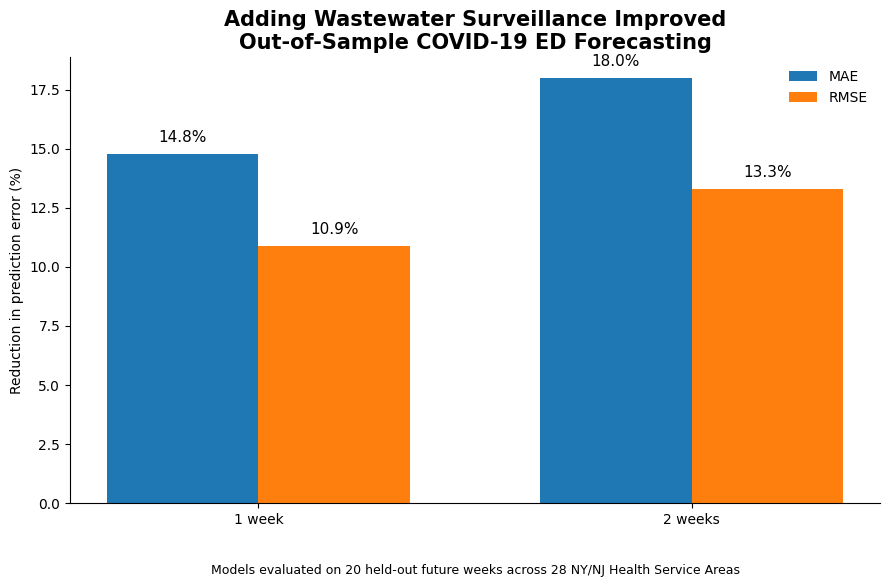

Figure saved ✅


In [56]:
# ============================================================
# FIGURE 1: FORECAST ERROR IMPROVEMENT
# ============================================================

import os
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("figures", exist_ok=True)

forecast_improvement = pd.DataFrame({
    "Forecast Horizon": [
        "1 week",
        "2 weeks"
    ],
    "MAE Improvement": [
        results_1w["mae_improvement"],
        results_2w["mae_improvement"]
    ],
    "RMSE Improvement": [
        results_1w["rmse_improvement"],
        results_2w["rmse_improvement"]
    ]
})

fig, ax = plt.subplots(figsize=(9, 6))

x = range(len(forecast_improvement))
width = 0.35

bars1 = ax.bar(
    [i - width/2 for i in x],
    forecast_improvement["MAE Improvement"],
    width,
    label="MAE"
)

bars2 = ax.bar(
    [i + width/2 for i in x],
    forecast_improvement["RMSE Improvement"],
    width,
    label="RMSE"
)

ax.set_xticks(list(x))
ax.set_xticklabels(
    forecast_improvement["Forecast Horizon"]
)

ax.set_ylabel("Reduction in prediction error (%)")

ax.set_title(
    "Adding Wastewater Surveillance Improved\n"
    "Out-of-Sample COVID-19 ED Forecasting",
    fontsize=15,
    fontweight="bold"
)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.4,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11
        )

ax.text(
    0.5,
    -0.16,
    "Models evaluated on 20 held-out future weeks across 28 NY/NJ Health Service Areas",
    transform=ax.transAxes,
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "figures/figure1_forecast_improvement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved ✅")

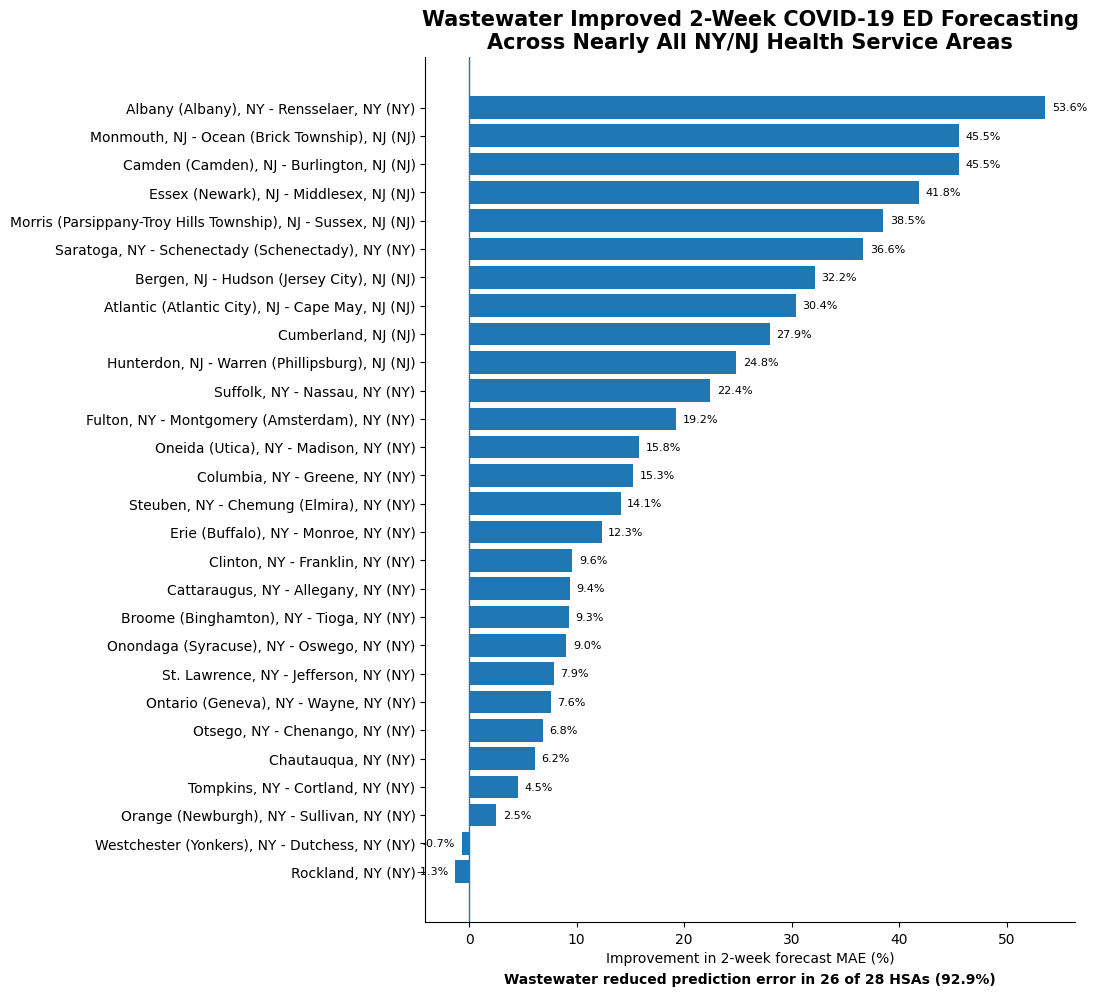

Figure 2 saved ✅


In [57]:
# ============================================================
# FIGURE 2: 2-WEEK FORECAST IMPROVEMENT ACROSS HSAs
# ============================================================

# Add readable HSA names
figure2_data = hsa_perf_2w.merge(
    hsa_svi[
        ["geography", "hsa_nci_id", "hsa"]
    ],
    on=["geography", "hsa_nci_id"],
    how="left"
)

# Create shorter plotting label
figure2_data["label"] = (
    figure2_data["hsa"]
    + " (" +
    figure2_data["geography"].str.replace("New Jersey", "NJ")
                               .str.replace("New York", "NY")
    + ")"
)

# Sort by wastewater-related improvement
figure2_data = figure2_data.sort_values(
    "mae_improvement_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(11, 10))

bars = ax.barh(
    figure2_data["label"],
    figure2_data["mae_improvement_pct"]
)

# Reference line: no forecasting benefit
ax.axvline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Improvement in 2-week forecast MAE (%)"
)

ax.set_ylabel("")

ax.set_title(
    "Wastewater Improved 2-Week COVID-19 ED Forecasting\n"
    "Across Nearly All NY/NJ Health Service Areas",
    fontsize=15,
    fontweight="bold"
)

# Add value labels
for bar, value in zip(
    bars,
    figure2_data["mae_improvement_pct"]
):

    if value >= 0:
        x_position = value + 0.6
        alignment = "left"
    else:
        x_position = value - 0.6
        alignment = "right"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        ha=alignment,
        fontsize=8
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.5,
    -0.07,
    "Wastewater reduced prediction error in 26 of 28 HSAs (92.9%)",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/figure2_hsa_forecast_improvement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 2 saved ✅")

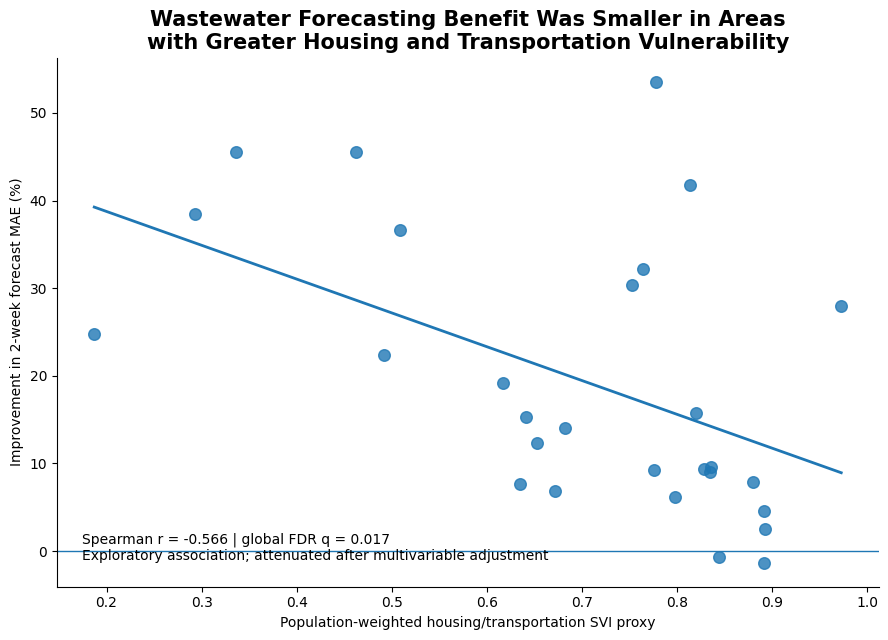

Figure 3 saved ✅


In [58]:
# ============================================================
# FIGURE 3: HOUSING/TRANSPORTATION VULNERABILITY
# VS 2-WEEK FORECAST IMPROVEMENT
# ============================================================

figure3_data = robust_2w[
    [
        "geography",
        "hsa_nci_id",
        "hsa_svi_housing_transport",
        "mae_improvement_pct"
    ]
].dropna().copy()

x = figure3_data["hsa_svi_housing_transport"]
y = figure3_data["mae_improvement_pct"]

# Simple linear trend for visualization
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = (
    slope * x_line
    + intercept
)

fig, ax = plt.subplots(figsize=(9, 6.5))

ax.scatter(
    x,
    y,
    s=70,
    alpha=0.8
)

ax.plot(
    x_line,
    y_line,
    linewidth=2
)

# Zero-improvement reference
ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Population-weighted housing/transportation SVI proxy"
)

ax.set_ylabel(
    "Improvement in 2-week forecast MAE (%)"
)

ax.set_title(
    "Wastewater Forecasting Benefit Was Smaller in Areas\n"
    "with Greater Housing and Transportation Vulnerability",
    fontsize=15,
    fontweight="bold"
)

# Key unadjusted result
ax.text(
    0.03,
    0.05,
    "Spearman r = -0.566 | global FDR q = 0.017\n"
    "Exploratory association; attenuated after multivariable adjustment",
    transform=ax.transAxes,
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/figure3_housing_transport_equity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 3 saved ✅")

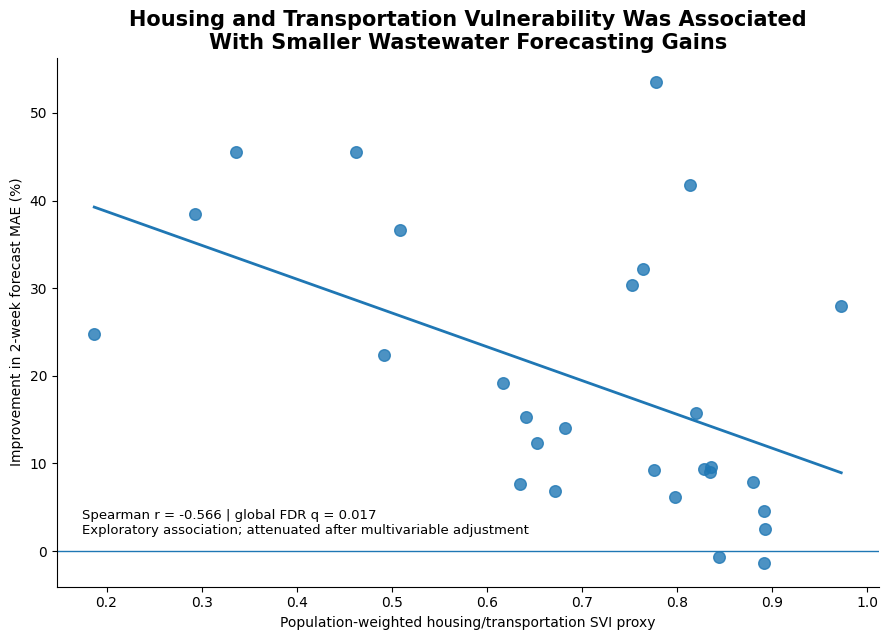

Final Figure 3 saved ✅


In [59]:
# ============================================================
# FINAL FIGURE 3: HOUSING/TRANSPORTATION EQUITY
# ============================================================

figure3_data = robust_2w[
    [
        "geography",
        "hsa_nci_id",
        "hsa_svi_housing_transport",
        "mae_improvement_pct"
    ]
].dropna().copy()

x = figure3_data["hsa_svi_housing_transport"]
y = figure3_data["mae_improvement_pct"]

# Linear trend for visualization only
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(9, 6.5))

ax.scatter(
    x,
    y,
    s=70,
    alpha=0.8
)

ax.plot(
    x_line,
    y_line,
    linewidth=2
)

# No improvement reference
ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Population-weighted housing/transportation SVI proxy"
)

ax.set_ylabel(
    "Improvement in 2-week forecast MAE (%)"
)

ax.set_title(
    "Housing and Transportation Vulnerability Was Associated\n"
    "With Smaller Wastewater Forecasting Gains",
    fontsize=15,
    fontweight="bold"
)

# Move annotation above zero line
ax.text(
    0.03,
    0.10,
    "Spearman r = -0.566 | global FDR q = 0.017\n"
    "Exploratory association; attenuated after multivariable adjustment",
    transform=ax.transAxes,
    fontsize=9.5
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/figure3_housing_transport_equity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final Figure 3 saved ✅")

In [61]:
# ============================================================
# SELECT A REPRESENTATIVE HSA FOR TIME-SERIES FIGURE
# ============================================================

representative_candidates = hsa_perf_2w.merge(
    hsa_coverage[
        [
            "geography",
            "hsa_nci_id",
            "hsa",
            "n_weeks",
            "mean_sites"
        ]
    ],
    on=["geography", "hsa_nci_id"],
    how="left"
)

representative_candidates = representative_candidates[
    (representative_candidates["mae_improvement_pct"] >= 15) &
    (representative_candidates["mae_improvement_pct"] <= 30) &
    (representative_candidates["n_weeks"] >= 80) &
    (representative_candidates["mean_sites"] >= 2)
].copy()

representative_candidates = representative_candidates.sort_values(
    "mae_improvement_pct",
    ascending=False
)

display(
    representative_candidates[
        [
            "geography",
            "hsa_nci_id",
            "hsa",
            "mae_improvement_pct",
            "n_weeks",
            "mean_sites"
        ]
    ]
)

,geography,hsa_nci_id,hsa,mae_improvement_pct,n_weeks,mean_sites
23,New York,83,"Suffolk, NY - Nassau, NY",22.433111,85,13.941176
18,New York,59,"Oneida (Utica), NY - Madison, NY",15.789750,86,6.104651


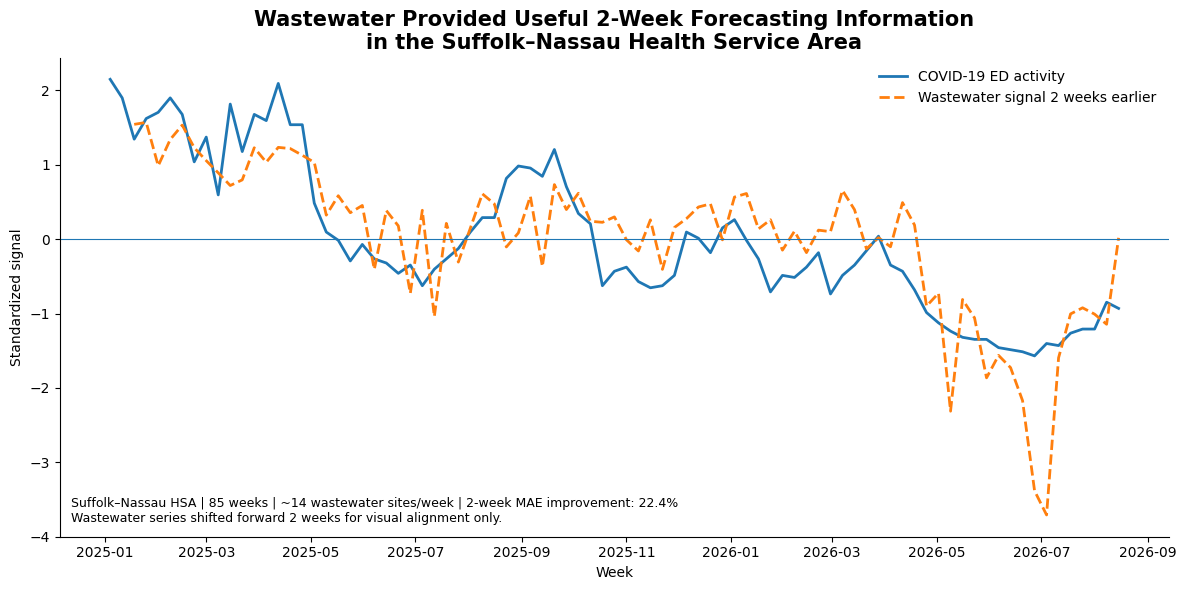

Figure 4 saved ✅


In [62]:
# ============================================================
# FIGURE 4: REPRESENTATIVE 2-WEEK EARLY-WARNING TIME SERIES
# Suffolk-Nassau HSA
# ============================================================

selected_state = "New York"
selected_hsa = "83"

fig4_data = forecast_model_data.loc[
    (forecast_model_data["geography"] == selected_state) &
    (forecast_model_data["hsa_nci_id"].astype(str) == selected_hsa)
].copy()

fig4_data = fig4_data.sort_values("week_end")

# ------------------------------------------------------------
# Standardize both series within this HSA FOR VISUALIZATION ONLY
# ------------------------------------------------------------

fig4_data["ww_plot_z"] = (
    fig4_data["wastewater_z"] -
    fig4_data["wastewater_z"].mean()
) / fig4_data["wastewater_z"].std(ddof=0)

fig4_data["ed_plot_z"] = (
    fig4_data["covid_ed_pct"] -
    fig4_data["covid_ed_pct"].mean()
) / fig4_data["covid_ed_pct"].std(ddof=0)

# Shift wastewater forward 2 weeks so wastewater at time t
# is visually aligned with ED activity at time t + 2 weeks
ww_shifted = fig4_data[
    ["week_end", "ww_plot_z"]
].copy()

ww_shifted["week_end"] = (
    ww_shifted["week_end"]
    + pd.to_timedelta(14, unit="D")
)

plot_data = fig4_data[
    ["week_end", "ed_plot_z"]
].merge(
    ww_shifted,
    on="week_end",
    how="left"
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    plot_data["week_end"],
    plot_data["ed_plot_z"],
    linewidth=2,
    label="COVID-19 ED activity"
)

ax.plot(
    plot_data["week_end"],
    plot_data["ww_plot_z"],
    linewidth=2,
    linestyle="--",
    label="Wastewater signal 2 weeks earlier"
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_ylabel("Standardized signal")

ax.set_xlabel("Week")

ax.set_title(
    "Wastewater Provided Useful 2-Week Forecasting Information\n"
    "in the Suffolk–Nassau Health Service Area",
    fontsize=15,
    fontweight="bold"
)

ax.legend(
    frameon=False,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.01,
    0.03,
    "Suffolk–Nassau HSA | 85 weeks | ~14 wastewater sites/week | "
    "2-week MAE improvement: 22.4%\n"
    "Wastewater series shifted forward 2 weeks for visual alignment only.",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "figures/figure4_suffolk_nassau_timeseries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 4 saved ✅")

In [63]:
# ============================================================
# SAVE FINAL PROJECT DATASETS + RESULTS
# ============================================================

import os
import pandas as pd

os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

# ------------------------------------------------------------
# 1. Final HSA-week analytic dataset
# ------------------------------------------------------------

analysis.to_csv(
    "data/final_hsa_weekly_analysis.csv",
    index=False
)

# ------------------------------------------------------------
# 2. HSA-level forecast performance
# ------------------------------------------------------------

hsa_perf_1w.to_csv(
    "data/hsa_forecast_performance_1week.csv",
    index=False
)

hsa_perf_2w.to_csv(
    "data/hsa_forecast_performance_2week.csv",
    index=False
)

# ------------------------------------------------------------
# 3. HSA-level SVI proxy
# ------------------------------------------------------------

hsa_svi.to_csv(
    "data/hsa_svi_proxy.csv",
    index=False
)

# ------------------------------------------------------------
# 4. Final equity analytic datasets
# ------------------------------------------------------------

equity_1w.to_csv(
    "data/equity_analysis_1week.csv",
    index=False
)

equity_2w.to_csv(
    "data/equity_analysis_2week.csv",
    index=False
)

# ------------------------------------------------------------
# 5. Model performance summary
# ------------------------------------------------------------

model_summary = pd.DataFrame({
    "forecast_horizon": [
        "1-week",
        "2-week"
    ],
    "mae_improvement_pct": [
        results_1w["mae_improvement"],
        results_2w["mae_improvement"]
    ],
    "rmse_improvement_pct": [
        results_1w["rmse_improvement"],
        results_2w["rmse_improvement"]
    ],
    "hsas_improved": [
        hsa_perf_1w["wastewater_improved"].sum(),
        hsa_perf_2w["wastewater_improved"].sum()
    ],
    "total_hsas": [
        len(hsa_perf_1w),
        len(hsa_perf_2w)
    ],
    "median_hsa_mae_improvement_pct": [
        hsa_perf_1w["mae_improvement_pct"].median(),
        hsa_perf_2w["mae_improvement_pct"].median()
    ]
})

model_summary.to_csv(
    "results/model_performance_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 6. Equity-domain results including global FDR
# ------------------------------------------------------------

global_results.to_csv(
    "results/svi_domain_equity_results.csv",
    index=False
)

print("=== FILE EXPORT COMPLETE ===")

for folder in ["data", "results", "figures"]:

    print(f"\n{folder.upper()}:")

    for file in sorted(os.listdir(folder)):
        print("✓", file)

=== FILE EXPORT COMPLETE ===

DATA:
✓ equity_analysis_1week.csv
✓ equity_analysis_2week.csv
✓ final_hsa_weekly_analysis.csv
✓ hsa_forecast_performance_1week.csv
✓ hsa_forecast_performance_2week.csv
✓ hsa_svi_proxy.csv

RESULTS:
✓ model_performance_summary.csv
✓ svi_domain_equity_results.csv

FIGURES:
✓ figure1_forecast_improvement.png
✓ figure2_hsa_forecast_improvement.png
✓ figure3_housing_transport_equity.png
✓ figure4_suffolk_nassau_timeseries.png


In [64]:
import shutil

shutil.make_archive(
    "Wastewater_Equity_Early_Warning_files",
    "zip",
    "."
)

print("ZIP created ✅")

ZIP created ✅
